INSTALL AND IMPORT SECTION

In [ ]:
!pip install stanza
!pip install rouge_score
!pip install tensorflow
!pip install nltk
!pip install psutil
!pip install bertviz
!pip install bert_score
!pip install pandas openpyxl
!pip install nvidia-ml-py3
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 35.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=c5d07a7f534c39d9b933d7d02873ce89d1e66a87db2ab7a26ada370639055493
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 104.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.p

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
from re import S
import tensorflow as tf
import torch
import torch.nn as nn
from transformers import AutoTokenizer
from transformers import RobertaModel, RobertaTokenizer
from openpyxl import Workbook

import pynvml
import math
import pandas as pd
from nltk.tokenize import sent_tokenize, word_tokenize
import html
import numpy as np
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

import re
import csv


import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
from rouge_score import rouge_scorer
from torch.nn.utils.rnn import pad_sequence
from pynvml import nvmlInit, nvmlDeviceGetHandleByIndex, nvmlDeviceGetMemoryInfo, nvmlDeviceGetUtilizationRates

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import random
import numpy as np
import stanza
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from torch.nn.utils.rnn import pad_sequence
from sklearn import model_selection
from sklearn.model_selection import train_test_split
import heapq
import gc
import time
from tqdm import tqdm
import torch.optim as optim

import matplotlib.pyplot as plt

import torch.nn as nn
from transformers import RobertaModel, RobertaConfig
from transformers import RobertaTokenizer
from bertviz import model_view
from transformers import logging
logging.set_verbosity_error()  # Suppress standard warnings
from bert_score import score
import glob
import time
import psutil
from torch.utils.data import Subset

MOUNT GOOGLE DRIVE

In [ ]:
#mount the Google drive so as to read the input files stored in the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


EMBEDDING SECTION


In [ ]:
#function to obtain Token embeddings for input_text
max_len=800 #no of tokens????  check this len in the model config also

def getTokenEncoding(seq_len, d, input_text, tokenizer):
    T= np.zeros((seq_len, d))  #T will be the token encoding list of dimension 512 x 768 initially filled with zeros
    input_ids =[] #list to hold the token ids of the sentences in the input_text
    attention_mask=[] #list to hold the attention masks of the sentences in the input_text


    for sentence in input_text:

            encoded_dict= tokenizer.encode_plus(sentence, return_attention_mask=True)  #text is converted to input ids and attention masks.
                                                                                        # this is kept in the encoded_dict
            input_ids.extend(encoded_dict['input_ids'])
            attention_mask.extend(encoded_dict['attention_mask'])

    input_ids = input_ids + [0] * (max_len - len(input_ids))  #truncating above maximum seq length
    attention_mask = attention_mask + [0] * (max_len - len(attention_mask ))    #truncating above maximum seq length

    attention_mask = attention_mask[:max_len]

    #fill the T array with the input_ids obtained
    for i in range(0, seq_len):
      for j in range(0, d):
        if i < len(input_ids):
          T[i][j] = input_ids[i]

    return T, input_ids, attention_mask

#function to obtain Position embeddings for input_text
def getPositionEncoding(seq_len, d, n=10000):
      P = np.zeros((seq_len, d))  #P will be the position encoding list of dimension 800(CNN/Dailymail) x 768 initially filled with zeros

      #using the sine and cosine formula for finding positional encoding
      for k in range(seq_len):
          for i in np.arange(int(d/2)):
              denominator = np.power(n, 2*i/d)
              P[k, 2*i] = np.sin(k/denominator)
              P[k, 2*i+1] = np.cos(k/denominator)
      return P

#s_max and s_min are the hyperparameters 1 and 2 in the positional encoding
#mu and sigma are the hyperparameters3 and 4 in the positional encoding
def getGaussianEncoding(seq_len, d, s_max, s_min, mu, sigma):
    #print("In gaussian encoding the scaling values :", s_max, s_min)
    G = np.zeros((seq_len, d))
    if mu is None:
        # Set means as linearly spaced across the sequence length
        mu = np.linspace(0, seq_len - 1, d)
    #gaussian components are calculated based on the passed mu and sigma values. So the start and end token positions
    # to be gaussian encoded is found as follows. This ensures we focus on the specified portion only
    start=mu-sigma
    end=mu+sigma
    # Compute Gaussian positional encodings

    '''we use linear scaling here: Linear Scaling: The Gaussian spreads increase gradually across dimensions,
     resulting in smoother transitions between local and global effects.Linear scaling ensures balanced local-global representation.'''
    dim_scaling = torch.linspace(s_min, s_max, d // 2)
    for k in range(start, end):
          #print(k)
          for i, scale in enumerate(dim_scaling):
                G[k, 2 * i] = np.exp(-((k - mu) ** 2) / (2 * (sigma * scale) ** 2))
                G[k, 2 * i + 1] = G[k, 2 * i]  # Match pairs... this is fine because the hybrid encoding sums up the sinusoidal and gaussian..
                                              # sinusoidal have unique values for even and odd positions , so added along with gaussian matching pairs
                                              # will result in hybrid encoding with unique even and odd position encoding

    return G



#function to obtain Gaussian Position embeddings for input_text
def getHybridEncoding(seq_len, d, s_max, s_min, mu, sigma, n=10000):
    """
    Generates hybrid positional encoding combining sinusoidal and Gaussian encodings.

    Args:
    - seq_len (int): Length of the sequence (number of positions).
    - d (int): Dimension of the encoding.
    - n (int): Base for the sinusoidal positional encoding formula (default: 10000).
    - sigma (float): Standard deviation for Gaussian encoding.

    Returns:
    - np.ndarray: A (seq_len x d) hybrid positional encoding matrix.
    """
    print("In hybrid encoding")
    # Get sinusoidal encoding
    sin_encoding = getPositionEncoding(seq_len, d, n)

    # Get Gaussian encoding
    gauss_encoding = getGaussianEncoding(seq_len, d, s_max, s_min, mu, sigma)

    # Combine sinusoidal and Gaussian encodings
    hybrid_encoding = sin_encoding + gauss_encoding

    return hybrid_encoding

#function to obtain Segment embeddings for input_text
def getSegmentEncoding(seq_len, d, indices):
      S = np.zeros((seq_len, d))  #S will be the segment encoding list of dimension 512 x 768 initially filled with zeros

      counter=0
      prev=0

      #from the obtained indices of [SEP] tokens, we identify the odd and even sentences and even sentences are marked as 0s and odd as 1s
      for j in indices:

          #print("Prev",prev)
          if counter%2==0:
            #print("Even index")
            for k in range(prev,j+1):
              for l in range(0, d):
                 S[k][l]=0
          else:
            #print("Odd index")
            for k in range(prev,j+1):
               for l in range(0, d):
                 S[k][l]=1


          counter=counter+1
          prev=j+1
      return S


#Class for obtaining the input embedding of a document which is the input to the RoBERTa encoder layer
class RoBertaDocumentEmbedder(nn.Module):
    def __init__(self):

        super(RoBertaDocumentEmbedder, self).__init__()
        self.bert = RobertaModel.from_pretrained('roberta-base')
        self.tokenizer = RobertaTokenizer.from_pretrained('roberta-base',cache_dir="./hf_cache", from_tf=True)


    def forward(self, input_text, s_max, s_min, mu, sigma):
        input_ids =[]
        #obtain the tokenixer
        tokenizer= RobertaTokenizer.from_pretrained('roberta-base', from_tf=True)


        #maximum sequence length of BERT is 512 and the dimension or #hidden layers= 768 (default values for BERT)
        seq_len=800
        d= 768

        #Obtain token embeddings
        T, input_ids, attention_mask = getTokenEncoding(seq_len, d, input_text, tokenizer)  # T will be the token encoding list of dimension 512 x 768
        token_ids= torch.tensor(T)   #convert T to tensor
        input_ids=input_ids[:seq_len]
        lenval=len(input_ids)  # required to find the indices of [SEP] tokens in the document for segment encoding
        token_ids = token_ids.unsqueeze(0)  # Add batch dimension so that now token_ids will be of size 1 x 512 x 768
        #print("Token embeddings: ")
        #print("________________________________________")
        #print(token_ids)
        #print(token_ids.shape)
        #print("________________________________________\n\n")
        '''print("Attention mask: ")
        print("________________________________________")
        print(attention_mask)'''
        attention_mask= torch.tensor(attention_mask)
        #print(attention_mask.shape)
        attention_mask = attention_mask.unsqueeze(0)  # Add batch dimension so that now attention_mask will be of size 1 x 512
        #print("________________________________________\n\n")
        #get the indices of [SEP] tokens in the document
        indices=[]
        count=0
        #print("Input ids")
        #print(input_ids)
        #print(len(input_ids))
        for i in input_ids:
          #print(i)
          if i==2:    # RoBERTa [SEP] token is 2 while BERT [SEP] token is 102. BERT [CLS] token is 101

            indices.append(count)
          count=count+1
        #print("Indices...............")
        #print(indices)

        #Obtain segment embeddings
        S= getSegmentEncoding(lenval, d, indices) # S will be the segment encoding list of dimension 512 x 768

        segment_ids= torch.tensor(S)  #convert S to tensor
        segment_ids = segment_ids.unsqueeze(0)  # Add batch dimension so that now segment_ids will be of size 1 x 512 x 768
        '''print("Segment embeddings")
        print("________________________________________")
        print(segment_ids)
        print(segment_ids.shape)
        print("________________________________________\n\n")'''

        #Obtain position embeddings
        Sinu= getPositionEncoding(lenval, d, n=10000) # Sinu will be the position encoding list of dimension 512 x 768
        #Gaussian= getGaussianEncoding(lenval, d, s_max, s_min, mu, sigma)
        P = getPositionEncoding(lenval, d, n=10000) # P will be the position encoding list of dimension 512 x 768
        #P= getGuassianPositionEncoding()
        H=getHybridEncoding(seq_len, d, s_max, s_min, mu, sigma, n=10000)
        position_ids= torch.tensor(H)  #change here according to P- sinu only, H- hybrid pos encoding
        #print(position_ids)
        position_ids = position_ids.unsqueeze(0)  # Add batch dimension so that now position_ids will be of size 1 x 512 x 768
        '''print("Position embeddings in consideration")
        print("________________________________________")
        print(position_ids)
        print(position_ids.shape)
        print("________________________________________\n\n")'''


        #The input embedding is the sum of token, segment and position embeddings
        sum_embeddings= token_ids + segment_ids + position_ids
        #print("Sum Embeddings")
        #print(sum_embeddings)

        #print("Sum embeddings shape: ",sum_embeddings.shape)
        #print("Attention shape: ", attention_mask.shape)

        #visualize_encoding(P, title="Hybrid Positional Encoding") #worked
        #visualize_encoding(Sinu, title="Sinusoidal Positional Encoding") #worked
        #visualize_encoding(sum_embeddings, title="Input embeddings")
        #print("_______________________________________________")
        #print("Exiting from Embedder !!!!!")
        #print("________________________________________________")
        return sum_embeddings, attention_mask, indices



MODEL DEFINITIONS

In [ ]:


class RoBERTA(nn.Module):
    def __init__(self, config, embeddings):
        super().__init__()


        config = RobertaConfig.from_pretrained("roberta-base", output_attentions=True) #OBTAIN THE CONFIGURATION OF ROBERTA
        config.update({"output_hidden_states":True,
                       "layer_norm_eps": 1e-7,"max_position_embeddings":1024})  #here is where you can configure the RoBERTA paramaeters
                       #IMPORATANT: EVEN IF THE MAX SEQUENCE LEN IS DEFAULT 512 AND FOR CNN/DAILYMAIL WE TAKE MAX SEQ LEN AS 800, THE
                       #ROBERTA CONFIG IS UPDATED WITH MAX_POSITION_EMBEDDINGS AS 1024. SETTING 800 THERE WILL RESULT IN ERROR.
                       #SO USE 512, 1024, 2048 ETC IF YOU WANT TO INCREASE THE SEQUENCE LENGTH
        #print(config)

        self.model = RobertaModel.from_pretrained("roberta-base",config=config,ignore_mismatched_sizes=True)
        self.embeddings = embeddings

        self.attention = nn.Sequential(
            nn.Linear(768, 128),  # Adjust hidden size as needed
            nn.Tanh(),
            nn.Linear(128, 768)  # Output a single attention weight per token
        )


        # Define a single layer of the transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=512, nhead=8)

        # Stack multiple layers to form the transformer encoder
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=12)


    def forward(self, input_embeddings, cls_indices, attention_mask):
        #print("PRINTiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiinnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnggggggggggggggggggg")

        input_embeddings = input_embeddings.type(torch.float32) #added this line

        #moving input embeddings and attention mask to gpu
        input_embeddings = input_embeddings.to(self.model.device)
        attention_mask= attention_mask.to(self.model.device)

        #print(input_embeddings)
        #print("Shapeeee:",input_embeddings.shape)  #1x 800x 768
        max_seq_len = self.model.config.max_position_embeddings
        #print("MAx seq len ", max_seq_len)

        #print(attention_mask.shape)
        #print("Call model")

        #next line takes the contextual embeddings from the last layer only
        outputs = self.model(inputs_embeds= input_embeddings, attention_mask=attention_mask, output_attentions=True)#generating the input contextual embedding
        embedding_output= outputs.last_hidden_state
        #IMPORTANT: SINCE WE ARE EXPLICITLY CREATING THE INPUT EMBEDDINGS, WE DIRECTLY GIVE THE GENERTED EMBEDDINGS TO THE MODEL
        #THAT IS WHY WE USE INPUTS_EMBEDS HERE, OTHERWISE IF WE ARE PASSING THE TENSORS OF THE INPUTS, WE HAVE TO USE INPUT_IDS INSTEAD OF
        #INPUTS_EMBEDS
        '''print("Embed output")
        print("Embedding output")
        print(embedding_output)
        print(embedding_output.shape)'''

        '''#im making change here: here we take the contextual embeddings from all layers

        outputs = self.model(inputs_embeds= input_embeddings)  #generating the input contextual embedding
        print("Out obtained")
        all_hidden_state = torch.stack(outputs[2])
        weighted_pooling_embeddings = self.pooler(all_hidden_state)'''

        #Code to obtain attention m
        attention_tup = outputs.attentions  # Retrieve attention from model outputs
        #attentions is a list of 12 elements (one for each layer),
        #each element is a tensor of shape [batch_size, num_heads, seq_len, seq_len].





        #print("Getting the cls embeddings from the last layer output")
        cls_embeddings = []
        for i in cls_indices:
          cls_embedding = embedding_output[:, i, :] #the earlier line of code when there was only the last layer output
          cls_embeddings.append(cls_embedding)
        cls_embeddings_tensor = torch.stack(cls_embeddings)
        #print("CLS token embeddings shape:", cls_embeddings_tensor.shape)
        #code change ends here'''


        #Here we are obtaining the embedding vectors of the [CLS] tokens only. For all sentemes we take the corresponding [CLS] tokens and create the embedding
        '''Where are the CLS Tokens in the Context Vector? Once you've computed the context vector:The CLS token embeddings are merged into
         the context vector through attention. They are no longer individually present as a separate part of the context vector.
         The context vector is the weighted sum of all token embeddings (including the CLS token), so there's no direct separation of the
         CLS token in the final context vector.If you need the CLS token's individual embedding for some purpose (e.g., classification),
         you can still extract it directly from the weighted_pooling_embeddings before computing the context vector:'''

        #print(cls_embeddings_tensor)
        #print("______________________________________________")
        #print("Exiting from RoBERTa model")
        #print("_________________________________________________")
        return cls_embeddings_tensor, attention_tup

'''# Example usage
config = RobertaConfig.from_pretrained('roberta-base')

# Example usage
s_max=5
s_min=1
mu= 400
sigma= 70

input_text = ['it is perceived as one of the most introverted countries in the world with a policy of eradicating any outside influence from foreign nations.', 'but a photographer s stunning collection of images from his journey through the republic of iran offers a rare insight into what life in the islamic state is really like.', 'with its tiny villages nestled into the side of mountains and picturesque farm land which is rarely seen by outsiders the country is as enchanting as it is mysterious.', 'but photographer amos chapple said the real surprise of persia was not its untouched and beautiful countryside but how different it is from western perceptions of the country .', 'palangan village in the mountains near the iraq border.', 'palangan illustrative of many of the country s rural settlements has benefited handsomely from government support.', 'many villagers are employed in a nearby fish farm or are paid members of the basij whose remit includes prevention of westoxification and the preservation of everything the 1979 islamic revolution and its leader the ayatollah khomeini stood for including strict rules on female clothing and male female interaction.', 'two shepherds lead palangan s flock of communally owned sheep out to pasture.', 'the government s spending in some rural regions has bought them a network of loyal followers who can be scrambled at any time to crush trouble in the urban centers.', 'rural basij were used as a part of the crackdown in 2009 which resulted in the deaths of seven anti government protestors.', 'a group of friends in the hills above tehran.', 'many every single one i met young iranians feel deeply embarrassed by their government and the way the nation is perceived abroad.', 'zac clayton a british cyclist who will finish a round the world cycle on march 23 described iran as having the kindest people of any country he cycled through.', 'i found most iranians particularly the younger generation to be very aware of the world around them... with a burning desire for the freedoms they feel they are being denied by an out of touch ultra conservative religious elite.', 'chapple from new zealand has visited the islamic republic of iran three times between december 2011 and january 2013 to accumulate his series of photographs.', 'and he claims while the government continues its anti western campaign he found a growing discontent among the country s youth who were embarrassed by the actions of its leaders.', 'he said i was amazed by the difference in western perceptions of the country and what i saw on the ground.', 'i think because access for journalists is so difficult people have a skewed image of what iran is the regime actually want to portray the country as a cauldron of anti western sentiment so they syndicate news footage of chanting nutcases which is happily picked up by overseas networks.', 'the mausoleum of ayatollah khomeini in tehran.', 'work on the unfinished building has dragged over 23 years.', 'with growing economic chaos in the country its completion is still nowhere in sight.', 'at the sa adabad palace complex in northern tehran islamic revolutionaries sawed a statue of the deposed shah in half.', 'today schoolchildren are taken on group visits past the boots and into the palace to see the decadence of the former shah s living quarters.', 'a young worker walks through the light of a stained glass window in the tehran bazaar.', 'under khomeini iranians were actively encouraged to produce large families.', 'by 2009 nearly 70 per cent of all iranians were under 30 but according to some reports the country is the least religious in the middle east.', 'instead of the armies for islam khomeini had called for the youthful population is now seen as the biggest threat to the deeply unpopular regime.', 'a commemorative plate of the former shah of iran in an antique store in shiraz.', 'the shah was given an authoritarian hold on power thanks to an mi6 and cia backed coup in 1953 which deposed prime minister mohammad mosaddegh and cost the lives of several hundreds of iranian citizens.', 'operation ajax was actioned after mosaddegh nationalized the petroleum industry of iran thus shutting out british dominance of an industry they had controlled since 1913.', 'that mosaddeqh had been a democratically elected leader with wide popular support fueled resentment at the shah who many saw as a brutal puppet for the west.', 'the anger at western intervention stoked strong initial support for the virulently anti western ayatollah khomeini.', 'azadi freedom tower the gateway to tehran designed in 1966 by a then 24 year old hossein amanat pictured left.']
model = RoBertaDocumentEmbedder( )
embeddings, attention_mask, sep_indices = model(input_text,s_max, s_min, mu, sigma)
print("shape of embeddings",embeddings.shape)
print("___________________________________________________________________")
print("Embeddings")
print(embeddings)
print("___________________________________________________________________")
#find the [CLS] indices from sep_indices list
new_list = [x+1 for x in sep_indices]
cls_indices= [0]+ new_list
cls_indices= cls_indices[:-1]
print(len(cls_indices))
print("___________________________________________________________________")
print("CLS indices")
print(cls_indices)
print("___________________________________________________________________")

#Attention mask
print(attention_mask.shape)  # Shape of the attention mask
print("Attention mask")
print(attention_mask)
print("___________________________________________________________________")

#After obtaining the embeddings call the RoBERTa model
  #create an object of RoBERTA class
custom_roberta_model = RoBERTA(config, embeddings)

#use the object to call the forward function of ROBERTA class
cls_embeddings_tensor, attention = custom_roberta_model(embeddings, cls_indices, attention_mask=attention_mask)
print(cls_embeddings_tensor.shape)
#The function returned the embeddings of all the [CLS] tokens
cls_embedding_reshaped= cls_embeddings_tensor.permute(1, 0, 2)


print(cls_embedding_reshaped.shape) # the output from RoBERTa is batchsize x #sentences(#[CLS] tokens) x dim(768)
#cls_embedding_reshaped = tf.squeeze(cls_embeddings_tensor, axis=1)

print("The attention is ")
print(attention)

for item in attention:
  print(item.size())'''



'# Example usage\nconfig = RobertaConfig.from_pretrained(\'roberta-base\')\n\n# Example usage\ns_max=5\ns_min=1\nmu= 400\nsigma= 70\n\ninput_text = [\'it is perceived as one of the most introverted countries in the world with a policy of eradicating any outside influence from foreign nations.\', \'but a photographer s stunning collection of images from his journey through the republic of iran offers a rare insight into what life in the islamic state is really like.\', \'with its tiny villages nestled into the side of mountains and picturesque farm land which is rarely seen by outsiders the country is as enchanting as it is mysterious.\', \'but photographer amos chapple said the real surprise of persia was not its untouched and beautiful countryside but how different it is from western perceptions of the country .\', \'palangan village in the mountains near the iraq border.\', \'palangan illustrative of many of the country s rural settlements has benefited handsomely from government sup

In [ ]:
#TRANSFORMER ENCODER LAYER DEFINITION (SUMMARIZATION LAYER)
d_ff = 2048
''' d_ff value is fixed based on d_model (input size)
In many architectures like the Transformer, d_ff is often set to be a multiple of d_model. A common default value is to set:
d_ff = 4 * d_model For example, in the original Transformer paper, the authors used d_ff = 2048 when d_model = 512.
This relationship is based on empirical results from their experiments and is a widely used default.'''

def gelu(x):
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

# Position wise feed forward network - Inside the transformer layer for Summarization
class PositionwiseFeedForward(nn.Module):
    """ A two-layer Feed-Forward-Network with residual layer norm.

    Args:
        d_model (int): the size of input for the first-layer of the FFN.
        d_ff (int): the hidden layer size of the second-layer
            of the FNN.
        dropout (float): dropout probability in :math:`[0, 1)`.
    """

    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.layer_norm = nn.LayerNorm(d_model, eps=1e-6)
        self.actv = gelu
        self.dropout_1 = nn.Dropout(dropout)
        self.dropout_2 = nn.Dropout(dropout)

    def forward(self, x):
        #print("Entering positionwise feed forward")
        x = x.to(self.w_2.weight.dtype)
        inter = self.dropout_1(self.actv(self.w_1(self.layer_norm(x))))
        output = self.dropout_2(self.w_2(inter))
        return output + x

#Multiheaded attention class -  Inside Transformer Layer for Summarization
class MultiHeadedAttention(nn.Module):
    def __init__(self, head_count, model_dim, dropout=0.1, use_final_linear=True):
        #print("Init MultiHeadedAttention Layer")
        assert model_dim % head_count == 0
        self.dim_per_head = model_dim // head_count
        self.model_dim = model_dim

        super(MultiHeadedAttention, self).__init__()
        self.head_count = head_count
        '''print("Head count", head_count)
        print("Dim_per_head", self.dim_per_head)
        print("Model dim", self.model_dim)'''
        self.linear_keys = nn.Linear(model_dim,
                                     head_count * self.dim_per_head)
        self.linear_values = nn.Linear(model_dim,
                                       head_count * self.dim_per_head)
        self.linear_query = nn.Linear(model_dim,
                                      head_count * self.dim_per_head)
        self.softmax = nn.Softmax(dim=-1)
        self.dropout = nn.Dropout(dropout)
        self.use_final_linear = use_final_linear
        if (self.use_final_linear):
            self.final_linear = nn.Linear(model_dim, model_dim)

    def forward(self, key, value, query, mask=None,
                layer_cache=None, type=None, predefined_graph_1=None):
        '''print("Entering MultiHeadedAttention")
        print(key.shape)
        print(key.dtype)
        print(value.shape)
        print(value.dtype)
        print(query.shape)
        print(query.dtype)
        print(mask.dtype)
        print(mask.shape)'''

        batch_size = key.size(0)
        device = self.linear_keys.weight.device
        key = key.to(device).to(self.linear_keys.weight.dtype)
        value = value.to(device).to(self.linear_values.weight.dtype)
        query = query.to(device).to(self.linear_query.weight.dtype)
        if mask is not None:
            mask = mask.to(device)
            #print("Batch size ", batch_size)



        dim_per_head = self.dim_per_head
        head_count = self.head_count
        key_len = key.size(1)
        query_len = query.size(1)

        def shape(x):
            """  projection """
            return x.view(batch_size, -1, head_count, dim_per_head) \
                .transpose(1, 2)

        def unshape(x):
            """  compute context """
            return x.transpose(1, 2).contiguous() \
                .view(batch_size, -1, head_count * dim_per_head)

        # 1) Project key, value, and query.
        if layer_cache is not None:
            if type == "self":
                #print("NOt none, self")
                query, key, value = self.linear_query(query), \
                                    self.linear_keys(query), \
                                    self.linear_values(query)

                key = shape(key)
                value = shape(value)

                if layer_cache is not None:
                    device = key.device
                    if layer_cache["self_keys"] is not None:
                        key = torch.cat(
                            (layer_cache["self_keys"].to(device), key),
                            dim=2)
                    if layer_cache["self_values"] is not None:
                        value = torch.cat(
                            (layer_cache["self_values"].to(device), value),
                            dim=2)
                    layer_cache["self_keys"] = key
                    layer_cache["self_values"] = value
            elif type == "context":
                #print("NOt none, context")
                query = self.linear_query(query)
                if layer_cache is not None:
                    if layer_cache["memory_keys"] is None:
                        key, value = self.linear_keys(key), \
                                     self.linear_values(value)
                        key = shape(key)
                        value = shape(value)
                    else:
                        key, value = layer_cache["memory_keys"], \
                                     layer_cache["memory_values"]
                    layer_cache["memory_keys"] = key
                    layer_cache["memory_values"] = value
                else:
                    print("Layer cache is None")
                    key, value = self.linear_keys(key), \
                                 self.linear_values(value)
                    key = shape(key)
                    value = shape(value)
        else:
            #print("None, no layer cache")
            key = self.linear_keys(key)
            #print("Key is ",key)
            value = self.linear_values(value)
            #print("Value is ",value)
            query = self.linear_query(query)
            #print("Query is ",query)

        key = shape(key)
        value = shape(value)
        query = shape(query)
        '''print("Key shape:", key.shape)
        print("Value shape:", value.shape)
        print("Query shape:", query.shape)'''
        key_len = key.size(2)
        query_len = query.size(2)

        # 2) Calculate and scale scores.
        #print("I reached here 2")
        query = query / math.sqrt(dim_per_head)
        #print(query)
        scores = torch.matmul(query, key.transpose(2, 3))
        #print(scores)
        #print(scores.shape)

        #if mask is not None:
         #   print("Applying mask to the scores")
          #  print(mask.shape)
           # mask = mask.unsqueeze(1).expand_as(scores)
            #scores = scores.masked_fill(mask, -1e18)

        # 3) Apply attention dropout and compute context vectors.

        attn = self.softmax(scores)
        #print("attention is ", attn)
        #print(attn.shape)
        if (not predefined_graph_1 is None):
            attn_masked = attn[:, -1] * predefined_graph_1
            attn_masked = attn_masked / (torch.sum(attn_masked, 2).unsqueeze(2) + 1e-9)

            attn = torch.cat([attn[:, :-1], attn_masked.unsqueeze(1)], 1)

        drop_attn = self.dropout(attn)

        #print("I reached here")
        if (self.use_final_linear):
            context = unshape(torch.matmul(drop_attn, value))
            output = self.final_linear(context)
            #print("Context :", output)
            #print(output.shape)
            return output
        else:
            context = torch.matmul(drop_attn, value)
            #print("ElseContext :", context)
            #print(context.shape)
            return context



#Classifier class
class Classifier(nn.Module):
    def __init__(self, hidden_size):
        super(Classifier, self).__init__()
        #print("Init Classifier Layer")
        self.linear1 = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, mask_cls):
        h = self.linear1(x).squeeze(-1)
        sent_scores = self.sigmoid(h) * mask_cls.float()
        return sent_scores





#Class TransformerEncoder
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, heads, d_ff, dropout):
        super(TransformerEncoderLayer, self).__init__()
        #print("Init TransformerEncoderLayer")
        self.self_attn = MultiHeadedAttention(
            heads, d_model, dropout=dropout)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.layer_norm = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, iter, query, inputs, mask):
        #print("Entering Transformerencoder Layer")
        #print("Iter ", iter)
        #print("Query ", query)
        #print("Inputs ", inputs)
        #print("Mask ", mask)
        if (iter != 0):
            #print("Calling layer norm")
            input_norm = self.layer_norm(inputs)
        else:
            #print(" NOT Calling layer norm")
            input_norm = inputs

        #print("MASK SHAPE",mask.shape)
        #mask=torch.tensor(mask)
        mask= mask.clone().detach()
        mask = mask.unsqueeze(1)

        #print("MASK SHAPE",mask.shape)
        context = self.self_attn(input_norm, input_norm, input_norm,
                                 mask=mask)
        inputs = inputs.to(context.device)  # <--- ADD THIS LINE
        out = self.dropout(context) + inputs
        #print("Out after dropout")
        #print(out)
        #print("Leaving Transformerencoder Layer")
        return self.feed_forward(out)





In [ ]:
#Inter sentence transformers
# this class contains init() function which takes in the number of intermediate layers as one of the
# parameter in our encoding scheme

class TransformerInterEncoder(nn.Module):
    #def __init__(self, d_model, d_ff, heads, dropout, num_inter_layers=0):
    def __init__(self, d_model, seq_len, num_inter_layers, dropout, heads=6):
        super(TransformerInterEncoder, self).__init__()
        self.d_model = d_model
        #print("D_model:",d_model)
        #print("Seqlen: ",seq_len)
        self.d_ff= seq_len
        self.num_inter_layers = num_inter_layers
        self.pos_emb = getPositionEncoding(seq_len, d_model, n=10000)
        self.transformer_inter = nn.ModuleList(
           [TransformerEncoderLayer(d_model, heads, d_ff, dropout)
            for _ in range(num_inter_layers)])
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(d_model, eps=1e-6)
        self.wo = nn.Linear(d_model, 1, bias=True)
        self.sigmoid = nn.Sigmoid()
    def forward(self, cls_embeddings_tensor, mask, cls_indices,d):

        batch_size, n_sents = cls_embeddings_tensor.size(0), cls_embeddings_tensor.size(1) #obtain the batch size and number of sentences
                                        # from the output of BERT encoder (vector of batchsize x seqlen x dimension, which is here 1 x 512 x 768)
        #print("Batch size: ", batch_size)
        #print("Number of sentences: ", n_sents)

        # to find the attention mask of [CLS] tokens of all sentences and store it in maskval
        maskval= np.zeros((n_sents, d))

        for k in cls_indices:
          for i in range(0, n_sents):
            for j in range(0, d):

                    val= mask[0][k]
                    integer_value = int(val.item())
                    maskval[i][j]=integer_value

        #print(maskval.shape)
        #cls_embeddings_tensor=cls_embeddings_tensor.detach().numpy() #convert tensor to numpy
        #cls_embeddings_tensor = cls_embeddings_tensor.cpu().detach().numpy()  #convert tensor to numpy
        #x = cls_embeddings_tensor * maskval #multiply the cls_embeddings_tensor with the attention mask
        x = cls_embeddings_tensor * torch.tensor(maskval).to(cls_embeddings_tensor.device) #multiply the cls_embeddings_tensor with the attention mask
        #print(x)
        #print(x.shape)

        #First step= h0= PosEmbed(T), T is the sentence vectors which is here cls_embeddings_tensor. Add the
        #positional embeddings of the sentences to the sentence vectors
        pos_emb= self.pos_emb #obtain the position embedding from the getPositionEncoding function
        #print(pos_emb.shape)
        # obtain the positional vectors of the [CLS] tokens of the sentences only using the [CLS] indices already found and stored in cls_indices
        posval= np.zeros((n_sents, d))
        for k in cls_indices:
          for i in range(0, n_sents):
            for j in range(0, d):
              posval[i][j]=pos_emb[k][j]
        #print(posval)
        #print(posval.shape)

        # STEP 1: ADD THE POSITIONAL VECTORS OF THE [CLS] TOKENS TO THE EMBEDDINGS OF [CLS] TOKENS OBTAINED FROM THE ROBERTA ENCODER
        #x = x + posval
        x = x + torch.tensor(posval).to(x.device)
        #print(x)
        #print(x.shape)
        #print(x.dtype)
        #x=torch.tensor(x)
        # STEP 2: NOW PASS THE OBTAINED X TO THE TRANSFORMER LAYERS, HERE THE NUMBER OF TRANSFORMER LAYERS IS A HYPERPARAMETER
        for i in range(self.num_inter_layers):
            #x = self.transformer_inter[i](i, x, x, 1 - maskval)  # all_sents * max_tokens * dim
            maskval_tensor = torch.tensor(maskval).to(x.device)
            x = self.transformer_inter[i](i, x, x, 1 - maskval_tensor)  # all_sents * max_tokens * dim
        #LAYER NORMALIZATION
        #LAYER NORMALIZATION
        #print("Applying layer norm")
        x = self.layer_norm(x)

        #print("Logits ")
        #print("**********************************************************************************************")
        #print(x)

        # CLASSIFIER LAYER
        #print("Applying Classifier layer")
        sent_scores = self.sigmoid(self.wo(x))
        #print("Sentence scores are:")
        #print("***************************************************************************************************")
        #print(sent_scores)
        #print("***************************************************************************************************")
        #print("Shape of sent_scores:",sent_scores.shape)
        sent_scores = sent_scores.squeeze(-1)
        #print("Shape of sent_scores after squeeze:",sent_scores.shape)

        return sent_scores, cls_indices,x   # return the sentence scores and Cls_indices
'''seq_len=1024
d=768
#print("calling Transformer InterEncoder")
interencoder = TransformerInterEncoder(d, seq_len)

result, cls_indices = interencoder(cls_embedding_reshaped, attention_mask, cls_indices,d)
#print(result)'''


'seq_len=1024\nd=768\n#print("calling Transformer InterEncoder")\ninterencoder = TransformerInterEncoder(d, seq_len)\n\nresult, cls_indices = interencoder(cls_embedding_reshaped, attention_mask, cls_indices,d)\n#print(result)'

STRATIFIED SAMPLING

In [ ]:
def get_lengths(doc):
    sentences = sent_tokenize(doc)
    num_sentences = len(sentences)
    num_tokens = len(word_tokenize(doc))
    return num_sentences, num_tokens

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp

def stratifiedd_sampling(train_article_ls, train_highlight_ls):

    df = pd.DataFrame({'article': train_article_ls, 'summary': train_highlight_ls})
    print(df)
    df[['num_sentences', 'num_tokens']] = df['article'].apply(lambda x: pd.Series(get_lengths(x)))
    # STEP 1: Create quantile bins on full dataset
    df['quantile_bin'] = pd.qcut(df['num_sentences'], q=100, labels=False, duplicates='drop')

    # STEP 2: Sample proportionally from each bin to get ~1000 documents
    sample_size = 1000
    bin_counts = df['quantile_bin'].value_counts().sort_index()
    print("Bin counts ", bin_counts)
    bin_sample_counts = (bin_counts / bin_counts.sum() * sample_size).round().astype(int)
    print("Bin sample counts: ", bin_sample_counts)
    # STEP 3: Perform stratified sampling
    subset_rows = []
    for bin_idx, n_samples in bin_sample_counts.items():
        bin_df = df[df['quantile_bin'] == bin_idx]
        sampled = bin_df.sample(n=min(n_samples, len(bin_df)), random_state=42)
        subset_rows.append(sampled)

    df_subset = pd.concat(subset_rows).reset_index(drop=True)

    #Plot the subset and full dataset graph
    sns.histplot(df['num_sentences'], bins=bin_counts.index.nunique(), stat='density', label='Full', color='blue', alpha=0.5, kde=True)
    sns.histplot(df_subset['num_sentences'], bins=bin_counts.index.nunique(), stat='density', label='Subset', color='orange', alpha=0.7, kde=True)
    plt.legend()
    plt.title("Document Length Distribution (Full vs Subset)")
    plt.xlabel("Number of Sentences")
    plt.ylabel("Density")
    plt.show()

    # STEP 4: Run KS Test to compare distributions
    statistic, p_value = ks_2samp(df['num_sentences'], df_subset['num_sentences'])

    print("KS Test Statistic:", statistic)
    print("p-value:", p_value)

    if p_value > 0.05:
        print("✅ Distributions are likely the same (fail to reject null hypothesis)")
    else:
        print("❌ Distributions are likely different (reject null hypothesis)")


    #convert subset_df back to two lists
    # Convert columns to separate lists
    list1 = df_subset['article'].tolist()
    list2 = df_subset['summary'].tolist()

    bin_counts = df_subset['quantile_bin'].value_counts().sort_index()
    print("Number of documents in each bin:")
    print(bin_counts)

    sns.barplot(x=bin_counts.index, y=bin_counts.values, palette='viridis')
    plt.xlabel("Length Bin (based on num_sentences)")
    plt.ylabel("Number of Documents")
    plt.title("Document Count per Bin")
    plt.show()


    return list1, list2


DATA LOADING AND PREPROCESSING

In [ ]:
#function to evaluate the summary using ROUGE scores

def rouge_calc(sys_summary, gold_summary, in_rouge1results,in_rouge2results, in_rougeLresults, in_rougeLsumresults):

  # Convert to single string if input is a list
  if isinstance(sys_summary, list):
        #print("REached first")
        sys_summary = " ".join(sys_summary)
  if isinstance(gold_summary, list):
        #print("REached second")
        gold_summary = " ".join(gold_summary)

  # initialize an empty string
  str1 = ""
  str2 = ""
  # traverse in the system summary
  for ele in sys_summary:
        str1 += ele

  # traverse in the gold summary
  for ele in gold_summary:
        str2 += ele



  #print("system summary")
  #print("######################")
  #print(str1)
  #print("______________________")
  #print("Gold summary")
  #print("#########################")
  #print(str2)
  #print("_____________________________")


  # a dictionary that will contain the results
  rouge1scorer = rouge_scorer.RougeScorer(['rouge1'])
  scores = rouge1scorer.score(str1, str2)
  #print("ROUGE1 SCORE", scores)
  precision, recall, fmeasure = scores['rouge1']
  # add them to the proper list in the dictionary
  in_rouge1results['precision'].append(precision)
  in_rouge1results['recall'].append(recall)
  in_rouge1results['fmeasure'].append(fmeasure)

  #rouge1precision=avg(rouge1results['precision'])

  rouge2scorer = rouge_scorer.RougeScorer(['rouge2'])
  scoress = rouge2scorer.score(str1, str2)
  #print("ROUGE2 SCORE", scoress)
  precision, recall, fmeasure = scoress['rouge2']
  # add them to the proper list in the dictionary
  in_rouge2results['precision'].append(precision)
  in_rouge2results['recall'].append(recall)
  in_rouge2results['fmeasure'].append(fmeasure)

  rougeLscorer = rouge_scorer.RougeScorer(['rougeL'])
  scoresss = rougeLscorer.score(str1, str2)
  #print("ROUGEL SCORE", scoresss)
  precision, recall, fmeasure = scoresss['rougeL']
  # add them to the proper list in the dictionary
  in_rougeLresults['precision'].append(precision)
  in_rougeLresults['recall'].append(recall)
  in_rougeLresults['fmeasure'].append(fmeasure)

  rougeLSscorer = rouge_scorer.RougeScorer(['rougeLsum'])
  scoressss = rougeLSscorer.score(str1, str2)
  #print("ROUGELSUM SCORE", scoresss)
  precision, recall, fmeasure = scoressss['rougeLsum']
  # add them to the proper list in the dictionary
  in_rougeLsumresults['precision'].append(precision)
  in_rougeLsumresults['recall'].append(recall)
  in_rougeLsumresults['fmeasure'].append(fmeasure)
  #scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL', 'rougeLsum'])
  #scores = scorer.score(str1, str2)
  #print("The Rouge score is ", scores)

  #print("Inside rougecalc function")
  #print(in_rouge1results)
  return in_rouge1results,in_rouge2results, in_rougeLresults, in_rougeLsumresults



In [ ]:
def calculate_bert(sys_summary, gold_summary, in_bertresults):
    """
    Calculate BERT score between reference (gold) summary and candidate (system) summary.
    :param reference: Reference summary as a string
    :param candidate: Candidate summary as a string
    :return: Precision, Recall, and F1-score
    """

    # Convert to single string if input is a list
    if isinstance(sys_summary, list):
        sys_summary = " ".join(sys_summary)
    if isinstance(gold_summary, list):
        gold_summary = " ".join(gold_summary)

    P, R, F1 = score([sys_summary], [gold_summary], lang='en')
    # Normalize by sentence length ratio to avoid overestimation/inflation of BERT score
    #length_penalty = min(len(gold_summary) / len(sys_summary), len(sys_summary) / len(gold_summary))

    in_bertresults['precision'].append(P.mean().item())
    in_bertresults['recall'].append(R.mean().item())
    in_bertresults['fmeasure'].append(F1.mean().item())
    return in_bertresults


LOADING DATASET

In [ ]:
def parse_story(path):
    with open(path, 'r', encoding='utf-8') as f:
        lines = f.read().split('\n')
    article, highlights = [], []

    article_lines = []
    highlight_lines = []
    next_is_highlight = False
    for line in lines:
              #print("Line read is :",line)
              if not line:
                  continue  # empty line
              elif line.startswith('@highlight'):
                  #print("I reached abs")
                  next_is_highlight = True
                  #highlights.append(line)
              elif next_is_highlight:
                  if(line!="\n"):
                    #print("In ",count,"  highlight")
                    highlights.append(line)
                    #print(highlights)

              else:
                  article_lines.append(line)

              article = '\n'.join(article_lines)
              abstract = '\n'.join(highlights)

            #print("abstract: ",abstract)
            #print("Article: ",article)


    return article, abstract

def stories_to_csv(folder, out_csv):
    rows = [('article', 'highlights')]

    j=0
    filecount=0
    for pathh in os.listdir(folder):
        # check if current path is a file
        if os.path.isfile(os.path.join(folder, pathh)):
            filecount += 1
            #print(filecount)
    print('File count:', filecount)
    article_lines = []
    highlight_lines = []
    train_article_ls = [0 for i in range(filecount)]
    train_highlight_ls = [0 for i in range(filecount)]

    for fname in os.listdir(folder):
        if not fname.endswith('.story'):
            continue
        art, hl = parse_story(os.path.join(folder, fname))
        rows.append((art, hl))
        train_article_ls[j]=art
        train_highlight_ls[j]=hl
        j=j+1

    with open(out_csv, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerows(rows)

    return rows, train_article_ls, train_highlight_ls



In [ ]:
def get_lengths(doc):
    sentences = sent_tokenize(doc)
    num_sentences = len(sentences)
    num_tokens = len(word_tokenize(doc))
    return num_sentences, num_tokens


In [ ]:
def load_data():
    # 🛠️ Step 1: Install required tools
    !pip install gdown nltk

    # 🧠 Step 2: Download CNN & DailyMail story archives
    !gdown https://drive.google.com/uc?id=0BwmD_VLjROrfTHk4NFg2SndKcjQ -O cnn_stories.tgz
    !gdown https://drive.google.com/uc?id=0BwmD_VLjROrfM1BxdkxVaTY2bWs -O dailymail_stories.tgz

    # 📂 Step 3: Extract the archives
    !mkdir -p cnn/stories dailymail/stories
    #!tar -xzf cnn_stories.tgz -C cnn --strip-components=1
    #!tar -xzf dailymail_stories.tgz -C dailymail --strip-components=1
    !tar -xvzf cnn_stories.tgz
    !tar -xvzf dailymail_stories.tgz
    # ✏️ Step 4: Parse and convert .story files to CSV
    import os, csv
    import nltk
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from nltk.tokenize import sent_tokenize, word_tokenize
    from scipy.stats import ks_2samp
    nltk.download('punkt')

    cnn_rows, cnn_train_article_ls, cnn_train_highlight_ls= stories_to_csv('cnn/stories', 'cnn_stories.csv')
    dailymail_rows, dm_train_article_ls, dm_train_highlight_ls= stories_to_csv('dailymail/stories', 'dailymail_stories.csv')

    print("✅ CSV files created: cnn_stories.csv and dailymail_stories.csv")

    # Copy to your Google Drive
    !cp cnn_stories.csv /content/drive/MyDrive/datasets/
    !cp dailymail_stories.csv /content/drive/MyDrive/datasets/
    print("CNN Exists:", os.path.exists("cnn_stories.csv"))
    print("DailyMail Exists:", os.path.exists("dailymail_stories.csv"))


    #Sampling using stratified sampling
    cnnarticles = [i for i, j in cnn_rows]
    cnnhighlights = [j for i, j in cnn_rows]
    #cnnlist1, cnnlist2=stratifiedd_sampling(cnnarticles, cnnhighlights)
    dmarticles = [i for i, j in dailymail_rows]
    dmhighlights = [j for i, j in dailymail_rows]


    return cnnarticles,cnnhighlights


In [ ]:
#PREPROCESSING FUNCTIONS


#function to convert to lowercase
def convert_lower_case(data):
    if isinstance(data, list):
        data = ' '.join(data)
    elif not isinstance(data, str):
        data = str(data)  # Convert non-string data to string


    return np.char.lower(data)

#remove punctuation symbols
def remove_punctuation(data):
    symbols = "!\"#$%&()*+-/:;<=>?@[\]^_`'{|}~"
    for i in range(len(symbols)):
        data = np.char.replace(data, symbols[i], ' ')
        data = np.char.replace(data, "  ", " ")
        data = np.char.replace(data, "‘", " ")
        data = np.char.replace(data, ',', '')
    return data

#function to remove apostrophe
def remove_apostrophe(data):
    data = np.char.replace(data, "'", "")
    data = np.char.replace(data, "'", "")
    return data



#main function to preprocess the data
def preprocess(data):

    data = convert_lower_case(data)

    data = remove_punctuation(data) #remove comma seperately

    data = remove_apostrophe(data)


    return data

In [ ]:
#PREPROCESSING THE DATASET

def preprocess_data(train_article_ls, train_highlight_ls):
  k=0
  train_src=[]
  print("****************************************************************")
  for article in train_article_ls:
      print("Preprocessing source ", k )

      train_src.append(preprocess(train_article_ls[k]))
      #print(train_src[k])
      k=k+1
  print("****************************************************************")
  print(train_src[1])
  l=0
  train_tgt=[]
  for article in train_highlight_ls:
      print("Preprocessing target ", l )
      train_tgt.append(preprocess(train_highlight_ls[l]))
      #print(train_tgt[l])
      l=l+1

  #COMBINING THE DOCUMENT-SUMMARY PAIR
  import numpy as np
  #combined_array = np.column_stack((train_article_ls, train_highlight_ls))
  combined_array = np.column_stack((train_src, train_tgt))
  #print(combined_array[0][0])
  #print("*******************************************8")
  #print(combined_array[0][1])


  gc.enable()
  #train_df, test_df = train_test_split(combined_array, test_size=0.3)
  #train_df, val_df=train_test_split(train_df, test_size=0.2)
  return train_src, train_tgt, combined_array

In [ ]:
#creating gold extractive summary from the given gold abstractive summary in the news documents.
''' What we have in the actual documents is the abstractive summary/highlights. So from these highlights we create an
extractIve summary by the following steps
For each sentence in the abstractive summary, we find 3 sentences from the source document which have the avg max ROUGE
score. these sentences are clubbed together to form the extractive summary
The extractive summary is sorted and duplicate sentences are removed.

The index of last sentence in the extractive summary is returned for each document. This is used for the mu and sigma parameter setting
'''

def create_extractive(myt, mydata, lenfact, target_labels):

  #print("In create_extractive fun")
  #print(">>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>")
  #print(lenfact)
  #what we get here is a single source-target document pair
  #print("TARGET...................")
  #print(myt) #target doc
  #print("SOURCE__________________________")
  #print(mydata) #source doc
  #print("Len of source document is ", len(mydata))
  extract=[]
  max_i=[]
  num_sentences = len(mydata)
  index_list=[]  #to store the indices of the sentences selected to be in the summary
  for tar in myt:   # for each highlight sentence in the abstractive summary
    #print("Source Sentence in consideration")
    #print(tar)
    rouge_prec=[]
    rouge_recall=[]
    rouge_fmeasure=[]
    count=1
    for src in mydata:  #for each sentence in the source document
      #print("Target Sentence in consideration")

      if count>lenfact:
        break

      #print("create Source sen:     ", count," : ",src)
      count=count+1

      rouge1scorer = rouge_scorer.RougeScorer(['rouge1'])
      scores = rouge1scorer.score(src, tar)
      precision1, recall1, fmeasure1 = scores['rouge1']

      rouge2scorer = rouge_scorer.RougeScorer(['rouge2'])
      scores = rouge2scorer.score(src, tar)
      precision2, recall2, fmeasure2 = scores['rouge2']

      rougeLscorer = rouge_scorer.RougeScorer(['rougeL'])
      scores = rougeLscorer.score(src, tar)
      precisionL, recallL, fmeasureL = scores['rougeL']
      # find the average of the rouge scores
      avg_precision=(precision1+precision2+precisionL)/3
      avg_recall=(recall1+recall2+recallL)/3
      avg_fmeasure=(fmeasure1+fmeasure2+fmeasureL)/3
      rouge_prec.append(avg_precision)
      rouge_recall.append(avg_recall)
      rouge_fmeasure.append(avg_fmeasure)
      #print(rouge_prec)
      #print(rouge_recall)
      #print(rouge_fmeasure)

    #print("Max len of sentences is ", count-1)
    #find the top 3 sentences from source document
    rouge_fmeasure=torch.tensor(rouge_fmeasure)
    num_sentences = rouge_fmeasure.size(0)
    k = min(3, num_sentences) # ensure k is not
    top_sents = torch.topk(rouge_fmeasure, k, dim=0)
    #print("Indices of top 3 sentences")
    #print(top_sents) #indices of top sentences ie the sentence number
    index_list.append(top_sents.indices)
    #print(index_list)
    for i in top_sents.indices:

      max_i.append(i)
      #print("i",i)
      #print(mydata[i])

      extract.append(mydata[i])

    for j in top_sents.indices:


  #print("the top sentences indices are ", top_sents.indices)
      doc_max=max(max_i)
  #print("The index of the last sentence in the summary is ", doc_max)

  # Sort the extractive summary by the order of indices
  ordered_summary_with_duplicates = [
        sentence for _, sentence in sorted(zip(max_i, extract), key=lambda x: x[0])
    ]

  # Remove duplicate sentences in the summary while preserving order
  seen = set()
  ordered_summary = []
  for sentence in ordered_summary_with_duplicates:
        if sentence not in seen:
            ordered_summary.append(sentence)
            seen.add(sentence)

  '''print("_____________________________________________________________________________")
  print("The extractive summary is ")
  print(ordered_summary)'''
  #print("the length of ordered_summary is ", len(ordered_summary))
  #print("_____________________________________________________________________________")


  #res = []
  #[res.append(x) for x in extract if x not in res]

  # printing list after removal
  #print ("The list after removing duplicates : "+ str(res))
  flat_list = torch.cat(index_list).tolist()  # to convert the index_list in tensor format to a simple list of indices

  return  ordered_summary, doc_max, flat_list #return the created extractive summary of the document and the index of the last sentence in the summary

  #return res



In [ ]:
import stanza

def funto_createextract(emp,combined_array, counter, use_gpu=True):
  nlp = stanza.Pipeline(lang='en', processors='tokenize', use_gpu=True)
  filecounter=1
  mysource=[]
  mytarget=[]
  extract_summary=[]
  row_counter=0
  rcount=0
  doc_maxcls=[]


  #print("Len of train_df ",len(train_df))
  for i in range(len(combined_array)):
      print("In funtocreateextract ", counter+1, " document")

      counter=counter+1
    #if filecounter<2:
      #print(f'********************** SourceDocument {filecounter} **********************************')
      #print("Create extract:", row_counter)
      inp=combined_array[i][0]
      doc = nlp(inp)

      mydata=[]

      for j, sentence in enumerate(doc.sentences):

        #print("j is ",j) #count of the number of sentences in the document

        mydata.append(sentence.text)

      #print( "Source in consideration :", mydata)
      #print("Len of source ", len(mydata))
      if mydata==[] or len(mydata)<3:
        emp=emp+1
        continue
      row_id = f"SrcDocument_{row_counter}"

      # Add the identifier and row data as a tuple
      mysource.append((row_id, mydata))

      row_counter += 1



      #print(f'********************** TargetDocument {filecounter} **********************************')
      out=combined_array[i][1]

      outdoc = nlp(out)

      mytar=[]
      for k, sentence in enumerate(outdoc.sentences):
        #print("Target in consideration:",sentence.text)
        mytar.append(sentence.text)

      #print("HIghlight:",mytar)
      mytar = ''.join(mytar[0])
      sentences = re.split(r'\n|\.\s*', mytar)

      #Filter out any empty strings resulting from the split
      sentences = [sentence.strip() for sentence in sentences if sentence.strip()]

      myt = []

      for sentence in sentences:
            myt.append(sentence)



      row_ids = f"TarDocument_{rcount}"

      # Add the identifier and row data as a tuple
      mytarget.append((row_ids, myt))


      rcount += 1


      filecounter=filecounter+1


  '''print("MY SOURCE")
  for row_id, row_data in mysource:
      print(f"{row_id}: {row_data}")
  print("MY TARGET")
  for row_id, row_data in mytarget:
      print(f"{row_id}: {row_data}")'''

  #print("Len of mysource ", len(mysource))
  #print("Len of mytarget ", len(mytarget))
  return mysource, mytarget, emp

#mysource contains rows in which each row stands for a single document where the sentences are seperated and listed.
#mytarget contains rows in which each row stands for a single document summary where the summary sentences are seperated and listed.

In [ ]:
# Example usage
def embedfun(mysource, mytarget, s_max, s_min, mu, sigma):

  embedder = RoBertaDocumentEmbedder()
  i=0
  sepidarr=[]
  extract_summary=[]
  doc_maxcls=[]
  #print("Mysource:", len(mysource))
  #print("Mytarget:", len(mytarget))
  #print("Calculating the length of all the documents and placing it in an array to help create the target_labels 2D array")
  row_lengths = []  # Each number is the length of a row
  for row in mysource:
    row_lengths.append(len(row[1]))
  length = max(row_lengths)
  #print("Length of each document")
  #print(row_lengths)
  #Initialising the 2D target_labels array with the different row lengths according to the different doc length
  target_labels = [[0 for _ in range(length)] for length in row_lengths]
  tl_count=0
  rcount=0
  for (row_id, row_data), (target_id, target_data) in zip(mysource, mytarget):
  #for row_id, row_data in mysource:
    #print(f"{row_id}: {row_data}")
    #print(f"{row_id}")
    print("Calling extractive summary generator for ", rcount+1, " doc")
    rcount=rcount+1
    input_text =row_data
    tar_text= target_data

    #print("#####################################################################################################")
    #print("________________________________________________________________")
    #print("In model ***********")
    '''print("Source document")
    print(input_text)
    print("Target document")
    print(tar_text)
    print("________________________________________________________________")
    print("#####################################################################################################")'''
    #print("Getting the embeddings of the document")
    embeddings, attention_mask, sep_indices = embedder(input_text, s_max, s_min, mu, sigma)
    #print("Embeddings")
    #print(embeddings)
    #print("Attention mask")
    #print(attention_mask)
    #print("Sep indices")
    #print(sep_indices)
    #find the [CLS] indices from sep_indices list
    new_list = [x+1 for x in sep_indices]
    cls_indices= [0]+ new_list
    cls_indices= cls_indices[:-1]
    '''print("CLS indices")
    print(cls_indices)'''
    #print("Len of CLS indices arr",len(cls_indices))

    #call the create_extractive function to create extractive summaries and store in the extract_summary list
    #extract_summary list contains the gold extractive summaries of all the documents



    ret_sum, clsind, flat_list= create_extractive(tar_text, input_text, len(cls_indices), target_labels)  # call create_extractive function to get the extractive summary for a document
    extract_summary.append(ret_sum)
    doc_maxcls.append(clsind)

    sepid= sep_indices[clsind]

    sepidarr.append(sepid)

    #flat_list contains the indices of sentences which are included in the created extractive summary.
    #So we take each row corresponding to each document and set those indices to 1 if that sentence is in the extractuve summary created
    for i in range(len(flat_list)):
      target_labels[tl_count][flat_list[i]]=1
    tl_count=tl_count+1


    #print("___________________________________________________________________")
    #print("CLS indices")
    #print(cls_indices)
    #print("___________________________________________________________________")

    #Attention mask
    #print(attention_mask.shape)  # Shape of the attention mask
    #print("Attention mask")
    #print(attention_mask)
    #print("___________________________________________________________________")
  '''print("the last sentence number of the extractive summary for each document ")
  print(doc_maxcls)
  print("THE GOLD EXTRACTIVE SUMMARY LIST IS")
  print(extract_summary)'''

  return sepidarr, extract_summary, doc_maxcls, target_labels

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class SummaryDataset(Dataset):
    def __init__(self, sources, targets, labels):
        self.sources = sources
        self.targets = targets
        self.labels = labels

    def __len__(self):
        return len(self.sources)

    def __getitem__(self, idx):
        return self.sources[idx], self.targets[idx], self.labels[idx]

# Custom collate function to handle variable-length sequences
def my_collate(batch):
    sources = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    labels = [item[2] for item in batch] # Assuming labels are numerical

    # Pad sources and targets to the maximum length within the batch
    # Find maximum length of sources and targets in the batch
    max_source_len = max(len(s) for s in sources)
    max_target_len = max(len(t) for t in targets)
    max_label_len= max(len(l) for l in labels)
    # Pad sources
    padded_sources = [s + [''] * (max_source_len - len(s)) for s in sources]

    # Pad targets
    padded_targets = [t + [''] * (max_target_len - len(t)) for t in targets]

    #Pad labels
    padded_labels= [l + [0] * (max_label_len - len(l)) for l in labels]
    #You might need to adjust padding based on data type
    #labels = pad_sequence(padded_labels, batch_first=True, padding_value=0)


    '''print("Len of padded src", len(padded_sources[0]))
    print("Len of padded tar",len(padded_targets[0]))
    print("Len of padded lab", len(padded_labels[0]))'''
    return padded_sources, padded_targets, padded_labels


In [ ]:
def loader_fun():
  cnntrain_article_ls, cnntrain_highlight_ls= load_data()
  list1, list2=stratifiedd_sampling(cnntrain_article_ls, cnntrain_highlight_ls)  #DO THIS FOR SAMPLING
  train_src, train_tgt, combined_array= preprocess_data(list1, list2)
  emp=0
  counter=0
  mysource, mytarget, emp = funto_createextract(emp, combined_array, counter)  #check is combined_array is the correct one???????????

  return mysource, mytarget

def call_embedfun(mysource, mytarget, s_max, s_min, mu, sigma):
  sepidarr,extract_summary, doc_maxcls, target_labels= embedfun(mysource, mytarget, s_max, s_min, mu, sigma)

  oldtarget=mytarget
  mytarget= extract_summary.copy()
  tardf = pd.DataFrame({'summary': mytarget})

# Save to CSV (one summary per row)
  tardf.to_csv('/content/drive/My Drive/CNNPosEmb/mytarget_summaries1000.csv', index=False)
  #print(mysource)
  #print("NEW target")
  #print(mytarget)

  # Generated binary labels for BCE loss calculation
  #print("Target labels calculated for loss calculation")
  #print(target_labels)

  # Flatten the structure to a single list of strings (sentences)
  flat_source_array=[]
  flat_tar_array=[]


  for rowid, row_data in mysource:
      #print(row_data)
      flat_source_array.append(row_data)
  flat_tar_array=mytarget.copy()





  dataset = SummaryDataset(flat_source_array, flat_tar_array, target_labels)
  #train_df, test_df = train_test_split(dataset, test_size=0.3)
  #train_df, val_df=train_test_split(train_df, test_size=0.2)

  from torch.utils.data import Subset

  train_df, test_df = train_test_split(dataset, test_size=0.3)
  train_df, val_df=train_test_split(train_df, test_size=0.2)


  # Use the custom collate function in the DataLoader
  train_loader = DataLoader(train_df, batch_size=8, shuffle=True, collate_fn=my_collate)
  val_loader = DataLoader(val_df, batch_size=8, shuffle=True, collate_fn=my_collate)
  test_loader = DataLoader(test_df, batch_size=8, shuffle=True, collate_fn=my_collate)

  '''for i in train_loader:
    print(i[0])
    print(i[1])
    print(i[2])'''

  data = {
    'source': flat_source_array,
    'target': flat_tar_array,
    'labels': target_labels
          }

  torch.save(data, '/content/drive/My Drive/CNNPosEmb/cnn_preprocessed1000.pt')

  return train_loader, val_loader, test_loader



In [ ]:
#Class Summary_gen : to generate the system summary
class Summary_gen(nn.Module):

    def __init__(self, sent_scores):
      self.sent_scores = sent_scores

    def forward(self, sent_scores, cls_indices, input_text):
      #generate a summary by taking the top 3 sentences with the max scores
      #print("In summaryGen")
      actual_sentences = [s for s in input_text if s.strip() != ""]
      actual_len = len(actual_sentences)

      print(f"Number of actual sentences: {actual_len}")
      '''for idx, sent in enumerate(actual_sentences):
          print(f"Sen {idx + 1}:", sent)'''
      if actual_len == 0:
          print("⚠️ No valid sentences to score.")
          top_sents = None
          sen_index = []
          summary = ""
      else:
          # Step 2: Trim sentence scores to actual length only
          sent_scores = self.sent_scores[:, :actual_len]  # shape: (1, actual_len)

          # Step 3: Get top-3 sentence scores and their indices
          top_sents = torch.topk(sent_scores, k=min(3, actual_len), dim=1)  # Avoid crash if < 3 sentences
          #print("Top-k sentence scores:", top_sents)

          # Step 4: Extract top sentence indices
          sen_index = top_sents.indices.squeeze().tolist()
          if isinstance(sen_index, int):  # Handle case when k=1 returns single int
              sen_index = [sen_index]

          #print("Selected sentence indices:", sen_index)

          # Optional Step 5: Collect selected sentences
          selected_summary = [actual_sentences[i] for i in sen_index]
          gen_summary = " ".join(selected_summary)
          #print("Generated Summary:\n", gen_summary)





      return gen_summary
    def _call_impl(self, *input, **kwargs):
        # Implement your custom logic here.
        # For example, you could call the forward method here.
        return self.forward(*input, **kwargs)

'''#print(result)
#print(result.shape)
sumgen= Summary_gen(result)
summary = sumgen(result,cls_indices,input_text)
print("The input text is ")
print(input_text)
print("The system generated summary is ")
print(summary)'''

'#print(result)\n#print(result.shape)\nsumgen= Summary_gen(result)\nsummary = sumgen(result,cls_indices,input_text)\nprint("The input text is ")\nprint(input_text)\nprint("The system generated summary is ")\nprint(summary)'

MEMORY USAGE TRACKING

In [ ]:
# Function to get current memory usage
def get_memory_usage():
    process = psutil.Process()
    return process.memory_info().rss  # in bytes


In [ ]:
def batchify_embeddings(embeddings_list, attention_masks, cls_indices_list, device):
    padded_embeddings = pad_sequence(embeddings_list, batch_first=True)
    padded_attention_masks = pad_sequence(attention_masks, batch_first=True)
    max_cls_len = max(len(cls) for cls in cls_indices_list)
    padded_cls_indices = torch.zeros(len(cls_indices_list), max_cls_len, dtype=torch.long)
    for i, cls in enumerate(cls_indices_list):
        padded_cls_indices[i, :len(cls)] = torch.tensor(cls)
    return padded_embeddings.to(device), padded_attention_masks.to(device), padded_cls_indices.to(device)

def build_target_tensor(batch_labels, max_num_sentences, device):
    batch_size = len(batch_labels)
    target_tensor = torch.zeros((batch_size, max_num_sentences), dtype=torch.float)
    for i, label_list in enumerate(batch_labels):
        length = min(len(label_list), max_num_sentences)
        target_tensor[i, :length] = torch.tensor(label_list[:length], dtype=torch.float)
    return target_tensor.to(device)


GPU usage tracking

In [ ]:
pynvml.nvmlInit()
handle = pynvml.nvmlDeviceGetHandleByIndex(0)  # GPU 0

def get_gpu_memory():
    mem = pynvml.nvmlDeviceGetMemoryInfo(handle)
    return mem.used / 1024**2  # Return in MiB

def get_gpu_utilization():
    return pynvml.nvmlDeviceGetUtilizationRates(handle).gpu  # %

# Optional: for pretty reporting
def format_time(seconds):
    mins = int(seconds // 60)
    secs = int(seconds % 60)
    return f"{mins}m {secs}s"


def monitor_gpu_usage():
    pynvml.nvmlInit()
    handle = pynvml.nvmlDeviceGetHandleByIndex(0)  # First GPU
    mem_info = pynvml.nvmlDeviceGetMemoryInfo(handle)
    util_rate = pynvml.nvmlDeviceGetUtilizationRates(handle)
    print(f"🧠 GPU Memory Used: {mem_info.used / 1024**2:.2f} MiB / {mem_info.total / 1024**2:.2f} MiB")
    print(f"📈 GPU Utilization: {util_rate.gpu}%")

In [ ]:
def log_gpu_metrics(epoch, doc_idx, csv_path="/content/drive/My Drive/CNNPosEmb/para_gpu_usage.csv"):
    pynvml.nvmlInit()
    handle = pynvml.nvmlDeviceGetHandleByIndex(0)
    mem_info = pynvml.nvmlDeviceGetMemoryInfo(handle)
    util = pynvml.nvmlDeviceGetUtilizationRates(handle)
    df = pd.DataFrame([{
        "Epoch": epoch,
        "DocIdx": doc_idx,
        "GPU_Memory_Used_MB": mem_info.used / 1024**2,
        "GPU_Utilization_Percent": util.gpu
    }])
    if not os.path.exists(csv_path):
        df.to_csv(csv_path, index=False)
    else:
        df.to_csv(csv_path, mode='a', header=False, index=False)

def move_to_device(tensor, device):
    if isinstance(tensor, torch.Tensor):
        return tensor.to(device)
    elif isinstance(tensor, list):
        return [t.to(device) if isinstance(t, torch.Tensor) else t for t in tensor]
    return tensor

In [ ]:
#def valid_fun(val_losses, val_loader, mysource, mytarget, s_max, s_min, mu, sigma, num_epochs=1, device="cuda"):
def valid_fun(config, custom_roberta_model, embedder, interencoder, logit_layer,val_losses, val_loader, s_max, s_min, mu, sigma, num_epochs=1, device="cuda"):
    val_in_rouge1results = {'precision': [], 'recall': [], 'fmeasure': []}
    val_in_rouge2results = {'precision': [], 'recall': [], 'fmeasure': []}
    val_in_rougeLresults = {'precision': [], 'recall': [], 'fmeasure': []}
    val_in_rougeLsumresults = {'precision': [], 'recall': [], 'fmeasure': []}
    val_in_bertresults= {'precision': [], 'recall': [], 'fmeasure': []}
    #val_in_bleuresults = {'score': []}
    d = 768
    seq_len = 800
    num_inter_layers = 2
    heads = 6
    dropout = 0.1


    print("__________________________________________________________")
    print(f"\n🚀 Validation with Parameters: s_max={s_max},s_min={s_min}, mu={mu}, sigma={sigma}")
    print("__________________________________________________________")

    # Set device (use GPU if available)
    # Set device (use GPU if available)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    custom_roberta_model.to(device)
    embedder.to(device)
    interencoder.to(device)
    logit_layer.to(device)

    custom_roberta_model.eval()
    embedder.eval()
    interencoder.eval()
    logit_layer.eval()

    # Define the optimizer, loss function, and scheduler
    betas = (0.9, 0.999)  # Momentum and RMS scaling as in base paper
    weight_decay = 1e-2  # L2 regularization
    optimizer = optim.AdamW(list(custom_roberta_model.parameters()) + list(logit_layer.parameters()),
                            lr=0.002, betas=betas, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.9)
    loss_fn = nn.BCEWithLogitsLoss()  # we take the raw output from the Interencoder(o/p: x) to calculate loss

    #lists to store the validation epoch losses

    best_val_loss = float('inf')
    #best_rougeL=-1

    total_loss = 0


    print(f"VALIDATION is starting for {num_epochs} epochs...")
    monitor_gpu_usage()
    # === Step 2: Training Loop ===
    for epoch in range(num_epochs):
        print(f"\n Epoch {epoch+1}/{num_epochs}...")




        val_loss = 0
        val_sentences = 0
        with torch.no_grad():
            for batch_id, (batch_sources, batch_targets, batch_labels) in enumerate(val_loader):
                #print("Batch id : ", batch_id)
                for doc_idx in range(len(batch_sources)):
                    input_text = batch_sources[doc_idx]
                    #print("Input text: ", input_text)
                    target_text = batch_targets[doc_idx]
                    tarlabel = batch_labels[doc_idx]
                    if len(input_text) == 0 or len(tarlabel) == 0:
                        continue

                    print(f"\n📄 Processing doc {batch_id * len(batch_sources) + doc_idx + 1}")
                    # Embedding
                    embeddings, attention_mask, sep_indices = embedder(input_text, s_max, s_min, mu, sigma)
                    cls_indices = [0] + [x + 1 for x in sep_indices][:-1]
                    cls_indices = [idx for idx in cls_indices if idx < config.max_position_embeddings]

                    '''embeddings = embeddings.to(device)
                    attention_mask = attention_mask.to(device)
                    cls_indices = torch.tensor(cls_indices).to(device)'''
                    embeddings = move_to_device(embeddings, device)
                    attention_mask = move_to_device(attention_mask, device)
                    cls_indices = torch.tensor(cls_indices).to(device)
                    # Forward pass
                    cls_embeddings_tensor, _ = custom_roberta_model(embeddings, cls_indices, attention_mask)
                    cls_embedding_reshaped = cls_embeddings_tensor.permute(1, 0, 2)
                    result, cls_indices, x = interencoder(cls_embedding_reshaped, attention_mask, cls_indices, d)

                    # === Step 4: Summary Generation ===
                    sumgen = Summary_gen(result)
                    generated_summary = sumgen(result, cls_indices, input_text)
                    print("Generated summary:")
                    print(generated_summary)

                    x = x.to(device)
                    logits = logit_layer(x).squeeze(-1)
                    target_tensor = torch.tensor(tarlabel[:x.size(1)]).float().to(device).unsqueeze(0)
                    loss = loss_fn(logits, target_tensor)

                    val_loss += loss.item() * target_tensor.numel()
                    #print(f"🧮 Valid Loss: {loss.item():.4f}")
                    val_sentences += target_tensor.numel()

                    # === Step 6: Evaluation Metrics ===
                    val_in_rouge1results, val_in_rouge2results, val_in_rougeLresults, val_in_rougeLsumresults = rouge_calc(
                generated_summary, target_text,
                val_in_rouge1results, val_in_rouge2results, val_in_rougeLresults, val_in_rougeLsumresults
            )
            val_in_bertresults = calculate_bert(generated_summary, target_text, val_in_bertresults)
            #val_in_bleuresults = calculate_bleu(generated_summary, target_text, val_in_bleuresults)
        avg_val_loss = val_loss / val_sentences if val_sentences > 0 else 0.0
        #print(f"📊 Average Validation Loss: {avg_val_loss:.4f}")
        val_losses.append(avg_val_loss)
        monitor_gpu_usage()





    val_avg_rouge1 = sum(val_in_rouge1results['fmeasure']) / len(val_in_rouge1results['fmeasure'])
    val_avg_rouge2 = sum(val_in_rouge2results['fmeasure']) / len(val_in_rouge2results['fmeasure'])
    val_avg_rougeL = sum(val_in_rougeLresults['fmeasure']) / len(val_in_rougeLresults['fmeasure'])
    val_avg_rougeLsum = sum(val_in_rougeLsumresults['fmeasure']) / len(val_in_rougeLsumresults['fmeasure'])
    #val_avg_bleu= sum(val_in_bleuresults['score']) / len(val_in_bleuresults['score'])
    val_avg_bert = sum(val_in_bertresults['fmeasure']) / len(val_in_bertresults['fmeasure'])


    print("✅ Validation completed successfully!")
    return val_losses, val_avg_rouge1, val_avg_rouge2, val_avg_rougeL, val_avg_rougeLsum, val_avg_bert, val_in_rouge1results, val_in_rouge2results, val_in_rougeLresults, val_in_rougeLsumresults, val_in_bertresults




In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from transformers import RobertaConfig
from nltk.translate.bleu_score import sentence_bleu
from rouge_score import rouge_scorer

def train_fun(train_loader,val_loader, s_max, s_min, mu, sigma, num_epochs=2, device="cuda"):
#def train_fun(train_loader,val_loader, mysource, mytarget, s_max, s_min, mu, sigma, num_epochs=2, device="cuda"):
    in_rouge1results = {'precision': [], 'recall': [], 'fmeasure': []}
    in_rouge2results = {'precision': [], 'recall': [], 'fmeasure': []}
    in_rougeLresults = {'precision': [], 'recall': [], 'fmeasure': []}
    in_rougeLsumresults = {'precision': [], 'recall': [], 'fmeasure': []}
    in_bertresults= {'precision': [], 'recall': [], 'fmeasure': []}

    checkpoint_dir = "/content/drive/My Drive/modelpaths"
    checkpoints = sorted(glob.glob(f"{checkpoint_dir}/para_temp_checkpoint_epoch*.pth"), reverse=True)


    d = 768
    seq_len = 800
    num_inter_layers = 2
    heads = 6
    dropout = 0.1

    best_val_rougeL=-1   #initial value for comparison
    save_path = f"/content/drive/My Drive/modelpaths/para_epoch{num_epochs}.pth"
    resume_doc_idx = 0


    print("__________________________________________________________")
    print(f"\n🚀 Training  and Validation with Parameters: s_max={s_max},s_min={s_min}, mu={mu}, sigma={sigma}")
    print("__________________________________________________________")

    # === Step 1: Initialize Model Components ===
    config = RobertaConfig.from_pretrained("roberta-base",output_attentions=True, max_position_embeddings=800)
    embedder = RoBertaDocumentEmbedder()
    interencoder = TransformerInterEncoder(d, seq_len, num_inter_layers, dropout, heads)
    logit_layer = nn.Linear(d, 1)

    # Set device (use GPU if available)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    embedder.to(device)
    custom_roberta_model = RoBERTA(config, embedder)
    custom_roberta_model.to(device)
    interencoder.to(device)
    logit_layer.to(device)


    # Define the optimizer, loss function, and scheduler
    betas = (0.9, 0.999)  # Momentum and RMS scaling as in base paper
    weight_decay = 1e-2  # L2 regularization
    optimizer = optim.AdamW(list(custom_roberta_model.parameters()) + list(logit_layer.parameters()),
                            lr=0.002, betas=betas, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.9)
    loss_fn = nn.BCEWithLogitsLoss()  # we take the raw output from the Interencoder(o/p: x) to calculate loss

    #lists to store the train epoch losses and validation epoch losses
    epoch_losses = []
    val_losses=[]

    # Load model checkpoint if exists
    start_epoch = 0
    try:
      print(checkpoints)
      if checkpoints:
                latest_checkpoint = checkpoints[0]
                checkpoint = torch.load(latest_checkpoint)

                model_state_dict = checkpoint['model_state_dict']
                custom_roberta_model.load_state_dict(checkpoint['model_state_dict'])
                interencoder.load_state_dict(checkpoint['interencoder_state_dict'])
                logit_layer.load_state_dict(checkpoint['logit_layer_state_dict'])
                optimizer = optim.AdamW(list(custom_roberta_model.parameters()) + list(logit_layer.parameters()),
                            lr=0.002, betas=betas, weight_decay=weight_decay)
                try:
                    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
                except ValueError as e:
                      print("⚠️ Optimizer state not loaded due to mismatch:", str(e))
                      print("Reinitializing optimizer from scratch.")
                if 'scheduler_state_dict' in checkpoint:
                    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
                start_epoch = checkpoint.get('epoch', 0) + 1  # resume from next epoch
                best_val_rougeL = checkpoint.get('val_rougeL', -1)
                resume_doc_idx =checkpoint.get('doc_idx',0)
                print("resume from ",resume_doc_idx)
                print(f"✅ Resuming from epoch {start_epoch} for doc no {resume_doc_idx} with best ROUGE-L: {best_val_rougeL}")

                # Remove unexpected key
                if 'pooler.layer_weights' in model_state_dict:
                    print("Removing unexpected key: pooler.layer_weights")
                    model_state_dict.pop('pooler.layer_weights')

                print(f"✅ Loaded checkpoint from {save_path}")

    except FileNotFoundError:
                print("🚀 No checkpoint found, starting training from scratch.")

    total_loss = 0
    all_generated_summaries = []
    all_reference_summaries = []

    monitor_gpu_usage()
    print(f"TRAINING is starting for {num_epochs} epochs...")

    # === Step 2: Training Loop ===
    for epoch in range(num_epochs):

        print(f"\n🔄 Epoch {epoch+1}/{num_epochs}...")
        monitor_gpu_usage()
        custom_roberta_model.train()
        embedder.train()
        interencoder.train()
        logit_layer.train()
        epoch_loss = 0
        total_sentences = 0


        for batch_id, (batch_sources, batch_targets, batch_labels) in enumerate(tqdm(train_loader)):
            #print("Batch id : ", batch_id)
            for doc_idx in range(len(batch_sources)):
                input_text = batch_sources[doc_idx]

                target_text = batch_targets[doc_idx]
                tarlabel = batch_labels[doc_idx]

                if len(input_text) == 0 or len(tarlabel) == 0:
                    continue  # Skip empty samples
                absolute_doc_index = batch_id * len(batch_sources) + doc_idx
                if absolute_doc_index < resume_doc_idx:
                    continue  # Skip previously completed docs
                print(f"\n🔄 Epoch {epoch+1}/{num_epochs}...📄 Processing doc {batch_id * len(batch_sources) + doc_idx + 1}")
                #print("Input text length:", len(input_text))
                #print("Target text length:", len(target_text))
                #print("Labels:", tarlabel)

                # === Step 1: Obtain Embeddings ===
                embeddings, attention_mask, sep_indices = embedder(input_text, s_max, s_min, mu, sigma)
                cls_indices = [0] + [x + 1 for x in sep_indices][:-1]
                cls_indices = [idx for idx in cls_indices if idx < config.max_position_embeddings]

                '''embeddings = embeddings.to(device)
                attention_mask = attention_mask.to(device)
                cls_indices = torch.tensor(cls_indices).to(device)'''
                embeddings = move_to_device(embeddings, device)
                attention_mask = move_to_device(attention_mask, device)
                cls_indices = torch.tensor(cls_indices).to(device)

                optimizer.zero_grad()

                # === Step 2: Forward Pass Through RoBERTa ===
                cls_embeddings_tensor, _ = custom_roberta_model(embeddings, cls_indices, attention_mask=attention_mask)
                cls_embedding_reshaped = cls_embeddings_tensor.permute(1, 0, 2)

                 # === Step 3: Transformer Encoder ===
                result, cls_indices, x = interencoder(cls_embedding_reshaped, attention_mask, cls_indices, d)

                #print("Result :",result)
                #print("CLS indices : ", cls_indices)

                # === Step 4: Summary Generation ===
                sumgen = Summary_gen(result)
                generated_summary = sumgen(result, cls_indices, input_text)
                print("Generated summary:")
                print(generated_summary)

                # === Step 5: Compute Loss ===
                # Convert target labels to tensor
                num_sentences = x.size(1)
                target_tensor = torch.tensor(tarlabel[:num_sentences]).float().to(device).unsqueeze(0)

                # === Step 5.1: Logit layer added ===
                ''' Purpose of logit_layer = nn.Linear(d, 1) After your interencoder, you get a sequence of sentence embeddings (x)
                 with shape [batch_size, num_sentences, d]. You want to score each sentence — is it summary-worthy or not?
                 So, you apply a linear projection from d (embedding size) → 1 (a single logit per sentence):   '''
                #x = x.to(device)
                x = move_to_device(x, device)
                logits = logit_layer(x).squeeze(-1)

                loss = loss_fn(logits, target_tensor)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(custom_roberta_model.parameters(), max_norm=1.0)
                optimizer.step()

                epoch_loss += loss.item() * target_tensor.numel()
                total_sentences += target_tensor.numel()

                monitor_gpu_usage()
                log_gpu_metrics(epoch + 1, batch_id * len(batch_sources) + doc_idx + 1)


                # === Step 6: Evaluation Metrics ===
                in_rouge1results, in_rouge2results, in_rougeLresults, in_rougeLsumresults = rouge_calc(
                    generated_summary, target_text,
                    in_rouge1results, in_rouge2results, in_rougeLresults, in_rougeLsumresults
                )
                in_bertresults = calculate_bert(generated_summary, target_text, in_bertresults)
                #in_bleuresults = calculate_bleu(generated_summary, target_text, in_bleuresults)
                if absolute_doc_index % 25 == 0:
                    checkpoint_path = f"/content/drive/My Drive/modelpaths/para_temp_checkpoint_epoch{epoch+1}_doc{doc_idx+1}.pth"
                    torch.save({
                        'epoch': epoch,
                        'doc_idx': absolute_doc_index,
                        'model_state_dict': custom_roberta_model.state_dict(),
                        'interencoder_state_dict': interencoder.state_dict(),
                        'logit_layer_state_dict': logit_layer.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'scheduler_state_dict': scheduler.state_dict(),
                        'val_rougeL': best_val_rougeL
                    }, checkpoint_path)
                    print(f"💾 Temp checkpoint saved after {doc_idx + 1} documents at {checkpoint_path}")

                # Save partial metrics to CSV
                csv_path = "/content/drive/My Drive/CNNPosEmb/para_training_metrics_log1000.csv"
                metrics = {
                        "Epoch": epoch + 1,
                        "DocIndex": doc_idx + 1,
                        "Train_ROUGE-1": sum(in_rouge1results['fmeasure']) / len(in_rouge1results['fmeasure']) if in_rouge1results['fmeasure'] else 0,
                        "Train_ROUGE-2": sum(in_rouge2results['fmeasure']) / len(in_rouge2results['fmeasure']) if in_rouge2results['fmeasure'] else 0,
                        "Train_ROUGE-L": sum(in_rougeLresults['fmeasure']) / len(in_rougeLresults['fmeasure']) if in_rougeLresults['fmeasure'] else 0,
                        "Train_ROUGE-LSum": sum(in_rougeLsumresults['fmeasure']) / len(in_rougeLsumresults['fmeasure']) if in_rougeLsumresults['fmeasure'] else 0,
                        "Train_BERTScore": sum(in_bertresults['fmeasure']) / len(in_bertresults['fmeasure']) if in_bertresults['fmeasure'] else 0
                    }
                df = pd.DataFrame([metrics])
                if not os.path.exists(csv_path):
                        df.to_csv(csv_path, index=False)
                else:
                        df.to_csv(csv_path, mode='a', header=False, index=False)
        # Update the learning rate
        scheduler.step()
        monitor_gpu_usage()
        avg_epoch_loss = epoch_loss / total_sentences if total_sentences > 0 else 0.0
        epoch_losses.append(avg_epoch_loss)
        #print(f"📉 Average training Loss for Epoch {epoch + 1}: {avg_epoch_loss:.4f}")

        #print("_________________________________________________________________________________________________________________________")





        val_losses, val_avg_rouge1, val_avg_rouge2, val_avg_rougeL, val_avg_rougeLsum, val_avg_bert, val_in_rouge1results, val_in_rouge2results, val_in_rougeLresults, val_in_rougeLsumresults, val_in_bertresults= valid_fun( config, custom_roberta_model, embedder, interencoder, logit_layer, val_losses, val_loader, s_max, s_min, mu, sigma, num_epochs=1, device="cuda")
        #print(f"✅ Validation ROUGE-L: {val_avg_rougeL:.4f}")

        # Create a dictionary for current epoch's metrics
        metrics = {
            "Epoch": epoch + 1,
            "TrainROUGE-1": in_rouge1results,
            "TrainROUGE-2": in_rouge2results,
            "TrainROUGE-L": in_rougeLresults,
            "TrainROUGE-Lsum": in_rougeLsumresults,
            "TrainBERTScore": in_bertresults,
            "ValidROUGE-1": val_in_rouge1results,
            "ValidROUGE-2": val_in_rouge2results,
            "ValidROUGE-L": val_in_rougeLresults,
            "ValidROUGE-Lsum": val_in_rougeLsumresults,
            "ValidBERTScore": val_in_bertresults
        }

        # Convert to a one-row DataFrame
        df = pd.DataFrame([metrics])

        # Append to CSV
        csv_path = "/content/drive/My Drive/CNNPosEmb/para_finalafterepochtraining_metrics_log1000.csv"
        if not os.path.exists(csv_path):
            df.to_csv(csv_path, index=False)
        else:
            df.to_csv(csv_path, mode='a', header=False, index=False)

        if val_avg_rougeL > best_val_rougeL:
                #print("Avg val rougeL ", val_avg_rougeL)
                #print("Current best rougeL ", best_val_rougeL)
                #print("Validation performance improved")
                #print("^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^")
                best_val_rougeL = val_avg_rougeL
                #print("NEw best is ", best_val_rougeL)
                torch.save({
                    'model_state_dict': custom_roberta_model.state_dict(),
                    'interencoder_state_dict': interencoder.state_dict(),
                    'logit_layer_state_dict': logit_layer.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict(),
                    'epoch': epoch,
                    'val_rougeL': val_avg_rougeL
                }, save_path)
                #print(f"💾Final Model checkpoint saved: {save_path}")



    #Find the average rouge1, rouge2, RougeL and RougeLsum scores for  the chromosome
    #print(len(in_rouge1results['fmeasure']))
    avg_rouge1 = sum(in_rouge1results['fmeasure']) / len(in_rouge1results['fmeasure'])
    avg_rouge2 = sum(in_rouge2results['fmeasure']) / len(in_rouge2results['fmeasure'])
    avg_rougeL = sum(in_rougeLresults['fmeasure']) / len(in_rougeLresults['fmeasure'])
    avg_rougeLsum = sum(in_rougeLsumresults['fmeasure']) / len(in_rougeLsumresults['fmeasure'])
    #avg_bleuscore= sum(in_bleuresults['score']) / len(in_bleuresults['score'])
    avg_bert = sum(in_bertresults['fmeasure']) / len(in_bertresults['fmeasure'])

    # Create a summary dictionary
    summary = {
          "ModelPath": save_path,
          "Train_Loss": epoch_losses if epoch_losses else 0,
          "Train_ROUGE-1": avg_rouge1,
          "Train_ROUGE-2": avg_rouge2,
          "Train_ROUGE-L": avg_rougeL,
          "Train_ROUGE-Lsum": avg_rougeLsum,
          "Train_BERTScore": avg_bert,
          "Val_Los": val_losses if val_losses else 0,
          "Val_ROUGE-1": val_avg_rouge1,
          "Val_ROUGE-2": val_avg_rouge2,
          "Val_ROUGE-L": val_avg_rougeL,
          "Val_ROUGE-Lsum": val_avg_rougeLsum,
          "Val_BERTScore": val_avg_bert
      }

      # Save to CSV
    summary_df = pd.DataFrame([summary])
    csv_path = "/content/drive/My Drive/CNNPosEmb/para_final_train_summary1000.csv"
    if not os.path.exists(csv_path):
          summary_df.to_csv(csv_path, index=False)
    else:
          summary_df.to_csv(csv_path, mode='a', header=False, index=False)
    return save_path, epoch_losses, avg_rouge1, avg_rouge2, avg_rougeL, avg_rougeLsum, avg_bert, val_losses, val_avg_rouge1, val_avg_rouge2, val_avg_rougeL, val_avg_rougeLsum, val_avg_bert

In [ ]:
def test_fun(test_loader,s_max, s_min, mu, sigma,  save_path):

    d = 768
    seq_len = 800
    num_inter_layers = 2
    heads = 6
    dropout = 0.1

    test_loss=0
    test_in_rouge1results = {'precision': [], 'recall': [], 'fmeasure': []}
    test_in_rouge2results = {'precision': [], 'recall': [], 'fmeasure': []}
    test_in_rougeLresults = {'precision': [], 'recall': [], 'fmeasure': []}
    test_in_rougeLsumresults = {'precision': [], 'recall': [], 'fmeasure': []}
    test_in_bertresults= {'precision': [], 'recall': [], 'fmeasure': []}


    # Load best model
    config = RobertaConfig.from_pretrained("roberta-base", output_attentions=True, max_position_embeddings=800)
    embedder = RoBertaDocumentEmbedder()
    interencoder = TransformerInterEncoder(d, seq_len, num_inter_layers, dropout, heads)
    logit_layer = nn.Linear(d, 1)

    # Set device (use GPU if available)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    custom_roberta_model = RoBERTA(config, embedder)


    checkpoint = torch.load(save_path,map_location=device)

    custom_roberta_model.load_state_dict(checkpoint['model_state_dict'])
    interencoder.load_state_dict(checkpoint['interencoder_state_dict'])
    logit_layer.load_state_dict(checkpoint['logit_layer_state_dict'])


    custom_roberta_model.to(device).eval()
    embedder.to(device).eval()
    interencoder.to(device).eval()
    logit_layer.to(device).eval()

    # Define the optimizer, loss function, and scheduler
    betas = (0.9, 0.999)  # Momentum and RMS scaling as in base paper
    weight_decay = 1e-2  # L2 regularization
    optimizer = optim.AdamW(list(custom_roberta_model.parameters()) + list(logit_layer.parameters()),
                            lr=0.002, betas=betas, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.9)
    loss_fn = nn.BCEWithLogitsLoss()  # we take the raw output from the Interencoder(o/p: x) to calculate loss


    test_sentences=0
    monitor_gpu_usage()
    print("TESTING STARTS ********************************************************************************")

    with torch.no_grad():
        for batch_id, (batch_sources, batch_targets, batch_labels) in enumerate(test_loader):
            #print("Batch id : ", batch_id)
            for doc_idx in range(len(batch_sources)):
                input_text = batch_sources[doc_idx]
                #print("Input text: ", input_text)
                target_text = batch_targets[doc_idx]
                tarlabel = batch_labels[doc_idx]
                if len(input_text) == 0 or len(tarlabel) == 0:
                        continue

                print(f"\n📄 Processing doc {batch_id * len(batch_sources) + doc_idx + 1}")
                embeddings, attention_mask, sep_indices = embedder(input_text, s_max, s_min, mu, sigma)
                cls_indices = [0] + [x + 1 for x in sep_indices][:-1]
                cls_indices = [idx for idx in cls_indices if idx < config.max_position_embeddings]

                embeddings = move_to_device(embeddings, device)
                attention_mask = move_to_device(attention_mask, device)
                cls_indices = torch.tensor(cls_indices).to(device)

                cls_embeddings_tensor, _ = custom_roberta_model(embeddings, cls_indices, attention_mask)
                cls_embedding_reshaped = cls_embeddings_tensor.permute(1, 0, 2)
                result, cls_indices, x = interencoder(cls_embedding_reshaped, attention_mask, cls_indices, d)

                sumgen = Summary_gen(result)
                generated_summary = sumgen(result, cls_indices, input_text)
                print(generated_summary)

                # === Step 5: Compute Loss ===
                # Convert target labels to tensor
                num_sentences = x.size(1)
                target_tensor = torch.tensor(tarlabel[:num_sentences]).float().to(device).unsqueeze(0)

                # === Step 5.1: Logit layer added ===
                ''' Purpose of logit_layer = nn.Linear(d, 1) After your interencoder, you get a sequence of sentence embeddings (x)
                 with shape [batch_size, num_sentences, d]. You want to score each sentence — is it summary-worthy or not?
                 So, you apply a linear projection from d (embedding size) → 1 (a single logit per sentence):   '''
                x = x.to(device)
                logits = logit_layer(x).squeeze(-1)
                loss = loss_fn(logits, target_tensor)




                test_loss += loss.item() * target_tensor.numel()
                test_sentences += target_tensor.numel()

                #print(f"🧮 Test Loss: {loss.item():.4f}")

                # === Step 6: Evaluation Metrics ===
            test_in_rouge1results, test_in_rouge2results, test_in_rougeLresults, test_in_rougeLsumresults = rouge_calc(
                generated_summary, target_text,
                test_in_rouge1results, test_in_rouge2results, test_in_rougeLresults, test_in_rougeLsumresults
            )
            test_in_bertresults = calculate_bert(generated_summary, target_text, test_in_bertresults)
            # Save partial metrics to CSV
            csv_path = "/content/drive/My Drive/CNNPosEmb/para_test_metrics_log1000.csv"
            metrics = {

                        "DocIndex": doc_idx + 1,
                        "Train_ROUGE-1": sum(test_in_rouge1results['fmeasure']) / len(test_in_rouge1results['fmeasure']) if test_in_rouge1results['fmeasure'] else 0,
                        "Train_ROUGE-2": sum(test_in_rouge2results['fmeasure']) / len(test_in_rouge2results['fmeasure']) if test_in_rouge2results['fmeasure'] else 0,
                        "Train_ROUGE-L": sum(test_in_rougeLresults['fmeasure']) / len(test_in_rougeLresults['fmeasure']) if test_in_rougeLresults['fmeasure'] else 0,
                        "Train_ROUGE-LSum": sum(test_in_rougeLsumresults['fmeasure']) / len(test_in_rougeLsumresults['fmeasure']) if test_in_rougeLsumresults['fmeasure'] else 0,
                        "Train_BERTScore": sum(test_in_bertresults['fmeasure']) / len(test_in_bertresults['fmeasure']) if test_in_bertresults['fmeasure'] else 0
                    }
            df = pd.DataFrame([metrics])
            if not os.path.exists(csv_path):
                        df.to_csv(csv_path, index=False)
            else:
                        df.to_csv(csv_path, mode='a', header=False, index=False)
        scheduler.step()
        monitor_gpu_usage()
        avg_test_loss = test_loss / test_sentences if test_sentences > 0 else 0.0
        #print(f"📊 Test Loss: {avg_test_loss:.4f}")
        #val_losses.append(avg_test_loss)
        #print(f"📊 Test Loss: {avg_test_loss:.4f}")


    test_avg_rouge1 = sum(test_in_rouge1results['fmeasure']) / len(test_in_rouge1results['fmeasure'])
    test_avg_rouge2 = sum(test_in_rouge2results['fmeasure']) / len(test_in_rouge2results['fmeasure'])
    test_avg_rougeL = sum(test_in_rougeLresults['fmeasure']) / len(test_in_rougeLresults['fmeasure'])
    test_avg_rougeLsum = sum(test_in_rougeLsumresults['fmeasure']) / len(test_in_rougeLsumresults['fmeasure'])
    #avg_bleuscore= sum(in_bleuresults['score']) / len(in_bleuresults['score'])
    test_avg_bert = sum(test_in_bertresults['fmeasure']) / len(test_in_bertresults['fmeasure'])

    print(test_avg_rouge1)
    print(test_avg_rouge2)
    print(test_avg_rougeL)
    print(test_avg_rougeLsum)
    print(test_avg_bert)


    print("✅ Testing completed successfully!")
    return test_in_rouge1results, test_in_rouge2results, test_in_rougeLresults, test_in_rougeLsumresults, test_loss, test_avg_rouge1, test_avg_rouge2, test_avg_rougeL, test_avg_rougeLsum, test_avg_bert



LOADING THE DATASET

In [ ]:
if os.path.exists('/content/drive/My Drive/CNNPosEmb/cnn_preprocessed1000.pt'):
    print("Loading existing dataset from My Drive/CNNPosEmb folder")
    data = torch.load('/content/drive/My Drive/CNNPosEmb/cnn_preprocessed1000.pt')
    dataset = SummaryDataset(data['source'], data['target'], data['labels'])
    print(len(dataset))
    train_df, test_df = train_test_split(dataset, test_size=0.2,random_state=42)
    train_df, val_df=train_test_split(train_df, test_size=0.2, random_state=42)
    print("Train df", len(train_df))
    print("Val df", len(val_df))
    print("Test df", len(test_df))
    train_loader = DataLoader(train_df, batch_size=8, shuffle=True, collate_fn=my_collate)
    val_loader = DataLoader(val_df, batch_size=8, shuffle=False, collate_fn=my_collate)
    test_loader = DataLoader(test_df, batch_size=8, shuffle=False, collate_fn=my_collate)
else:
    print("Loading dataset from scratch...........................................................")
    mysource, mytarget = loader_fun()
    train_loader, val_loader, test_loader = call_embedfun(mysource, mytarget, s_max=0, s_min=0, mu=0, sigma=0)

Loading existing dataset from My Drive/CNNPosEmb folder
1000
Train df 640
Val df 160
Test df 200


In [ ]:
'''batch_size=4

Train loader: 6382 //4 = 798 batches ✅

Validation loader: 1596 // 4 = 200 batches ✅

Test loader: 1995 // 4 = 249 batches → 250 due to last partial batch ✅'''
print("Train df", len(train_df))
print("Val df", len(val_df))
print("Test df", len(test_df))

print("Len of train_loader", len(train_loader))
print("Len of valid loader", len(val_loader))
print("Len of test loader", len(test_loader))

Train df 640
Val df 160
Test df 200
Len of train_loader 80
Len of valid loader 20
Len of test loader 25


In [ ]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
import subprocess
result = subprocess.run(['echo $?'], shell=True, capture_output=True, text=True)
exit_code = int(result.stdout.strip())

if exit_code == 0:
    print("✅ Successfully connected to Hugging Face.")
else:
    print("❌ Failed to connect to Hugging Face. Please check your internet connection or firewall.")


✅ Successfully connected to Hugging Face.


In [ ]:
rouge1results = {'precision': [], 'recall': [], 'fmeasure': []}
rouge2results = {'precision': [], 'recall': [], 'fmeasure': []}
rougeLresults = {'precision': [], 'recall': [], 'fmeasure': []}
rougeLsumresults = {'precision': [], 'recall': [], 'fmeasure': []}

val_rouge1results = {'precision': [], 'recall': [], 'fmeasure': []}
val_rouge2results = {'precision': [], 'recall': [], 'fmeasure': []}
val_rougeLresults = {'precision': [], 'recall': [], 'fmeasure': []}
val_rougeLsumresults = {'precision': [], 'recall': [], 'fmeasure': []}

# Initialize NVML for GPU monitoring
nvmlInit()
handle = nvmlDeviceGetHandleByIndex(0)

#start the timer for capturing the cpu time required for training the model with 1500 docs and applying GA to find the optimal hyperprameters
st = time.process_time()
print("🟢 Starting GPU usage tracking...")
start_time = time.time()
start_mem = get_gpu_memory()
max_gpu_util = 0


# Track memory usage during training

initial_memory = get_memory_usage()



#For sinusoidal positional encoding
#s_max=s_min=mu=sigma=0
#For hybrid positional encoding, we take the best hyperparameters from the GA experiment
s_max=2
s_min=0.3
mu= 260
sigma= 65


save_path, epoch_losses, avg_rouge1, avg_rouge2, avg_rougeL, avg_rougeLsum, avg_bert, val_losses, val_avg_rouge1, val_avg_rouge2, val_avg_rougeL, val_avg_rougeLsum, val_avg_bert=train_fun(train_loader,val_loader, s_max, s_min, mu, sigma, num_epochs=2, device="cuda")
print("TRAINING::::::::::::::::average of all the rouge scores of the documents within all epochs")
print("Rouge1: ", avg_rouge1)
print("Rouge2: ", avg_rouge2)
print("RougeL: ", avg_rougeL)
print("RougeLsum: ", avg_rougeLsum)
print("Bert score: ", avg_bert)

print("VALIDATION::::::::::::::::average of all the rouge scores of the documents within all epochs")
print("Rouge1: ", val_avg_rouge1)
print("Rouge2: ", val_avg_rouge2)
print("RougeL: ", val_avg_rougeL)
print("RougeLsum: ", val_avg_rougeLsum)
print("Bert score: ", val_avg_bert)

print("Training-----Epoch losses")
print(epoch_losses)
# Plotting the loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o', linestyle='-', color='blue')
plt.title('Training-----Average Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.xticks(range(1, len(epoch_losses) + 1))
plt.tight_layout()
plt.show()
plt.savefig(f"/content/drive/My Drive/lossgraphs/para_training_loss_cnn.png")
print("Validation-----Epoch losses")
print(val_losses)
# Plotting the loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', linestyle='-', color='blue')
plt.title('Validation-----Average Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.xticks(range(1, len(epoch_losses) + 1))
plt.tight_layout()
plt.show()
plt.savefig(f"/content/drive/My Drive/lossgraphs/para_valid_loss_cnn.png")


print("✅ Training  and validation completed successfully !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!" )


et = time.process_time()

# get execution time
cputimee = et - st
print('Training CPU Execution time:', cputimee, 'seconds')

final_memory = get_memory_usage()

memory_used = final_memory - initial_memory
print(f"Memory used for training and validation: {memory_used / 1024 ** 2} MB")


end_time = time.time()
end_mem = get_gpu_memory()

print("\n📊 GPU USAGE SUMMARY")
print(f"⏱️ Duration: {format_time(end_time - start_time)}")
print(f"🧠 Memory used (start → end): {start_mem:.2f} MiB → {end_mem:.2f} MiB- Mebibytes") #Mebibyte
print(f"📈 Max GPU Utilization observed: {max_gpu_util}%")
#Because GPU memory is allocated and measured in powers of 2, MiB is more accurate than MB for system-level memory reporting.
#That’s why libraries like pynvml or torch.cuda.memory_allocated() report values in MiB.

🟢 Starting GPU usage tracking...
__________________________________________________________

🚀 Training  and Validation with Parameters: s_max=2,s_min=0.3, mu=260, sigma=65
__________________________________________________________


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Using device: cuda


KeyboardInterrupt: 

TEST function based on the best model

In [ ]:
checkpoint_dir = "/content/drive/My Drive/modelpaths"
checkpoints = sorted(glob.glob(f"{checkpoint_dir}/para_epoch*.pth"), reverse=True)
print(checkpoints)
latest_checkpoint = None
if checkpoints:
                latest_checkpoint = checkpoints[0]
test_in_rouge1results, test_in_rouge2results, test_in_rougeLresults, test_in_rougeLsumresults, test_loss, test_avg_rouge1, test_avg_rouge2, test_avg_rougeL, test_avg_rougeLsum, test_avg_bert=test_fun(test_loader,s_max, s_min, mu, sigma,latest_checkpoint )
print("Test-----Epoch losses")
print(test_loss)
print("Test-----Average Rouge1")
print(test_avg_rouge1)
print("Test-----Average Rouge2")
print(test_avg_rouge2)
print("Test-----Average RougeL")
print(test_avg_rougeL)
print("Test-----Average RougeLsum")
print(test_avg_rougeLsum)
print("Test-----Average BERT score")
print(test_avg_bert)

['/content/drive/My Drive/modelpaths/para_epoch2.pth']


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


🧠 GPU Memory Used: 7061.88 MiB / 15360.00 MiB
📈 GPU Utilization: 26%
TESTING STARTS ********************************************************************************

📄 Processing doc 1
In hybrid encoding


/tmp/ipython-input-7-4165166490.py:62: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  G[k, 2 * i] = np.exp(-((k - mu) ** 2) / (2 * (sigma * scale) ** 2))
/tmp/ipython-input-7-4165166490.py:62: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  G[k, 2 * i] = np.exp(-((k - mu) ** 2) / (2 * (sigma * scale) ** 2))
/tmp/ipython-input-7-4165166490.py:62: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  G[k, 2 * i] = np.exp(-((k - mu) ** 2) / (2 * (sigma * scale) ** 2))
/tmp/ipython-input-7-4165166490.py:62: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  G[k, 2 * i] = np.exp(-((k - mu) ** 2) / (2 * (sigma * scale) ** 2))
/tmp/ipython-input-7

Number of actual sentences: 31
his teacher joyce burnett who is also visually impaired spent two weeks before the circus visit preparing the kids in the classroom for the unique experience. during a stop in atlanta georgia children from the center for the visually impaired got more than a front row seat. an audience of 20 pre schoolers clapped and squealed as the elephant was handed a tiny harmonica and started playing.

📄 Processing doc 2
In hybrid encoding


...

Number of actual sentences: 16
nigerian police told cnn that boko haram an islamist sect that has challenged nigeria s government is responsible for the attacks which they described as an attempt to intimidate voters who this month re elected president goodluck jonathan an ljaw christian from the south. in one of three blasts a bomb thrown from a motorcycle on which two young men were riding detonated resulting in the three fatalities said michael zukoma police commissioner for borno state. cnn bomb blasts monday in nigeria s northeastern state of borno killed three people and wounded dozens raising fears that an islamist group will step up attacks against voters on the eve of national governorship elections police said.

📄 Processing doc 199
In hybrid encoding


/tmp/ipython-input-7-4165166490.py:62: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  G[k, 2 * i] = np.exp(-((k - mu) ** 2) / (2 * (sigma * scale) ** 2))
/tmp/ipython-input-7-4165166490.py:62: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  G[k, 2 * i] = np.exp(-((k - mu) ** 2) / (2 * (sigma * scale) ** 2))
/tmp/ipython-input-7-4165166490.py:62: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  G[k, 2 * i] = np.exp(-((k - mu) ** 2) / (2 * (sigma * scale) ** 2))
/tmp/ipython-input-7-4165166490.py:62: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  G[k, 2 * i] = np.exp(-((k - mu) ** 2) / (2 * (sigma * scale) ** 2))
/tmp/ipython-input-7

Number of actual sentences: 34
1 ranking and claim the 50th wta tour crown of her career becoming only the 10th player to do so. the american triumphed 6 1 6 4 to retain her no. cnn serena williams is looking forward to the ultimate challenge of trying to win the french open after again proving her dominance over biggest rival maria sharapova and defending her madrid title on sunday.

📄 Processing doc 200
In hybrid encoding


/tmp/ipython-input-7-4165166490.py:62: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  G[k, 2 * i] = np.exp(-((k - mu) ** 2) / (2 * (sigma * scale) ** 2))
/tmp/ipython-input-7-4165166490.py:62: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  G[k, 2 * i] = np.exp(-((k - mu) ** 2) / (2 * (sigma * scale) ** 2))
/tmp/ipython-input-7-4165166490.py:62: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  G[k, 2 * i] = np.exp(-((k - mu) ** 2) / (2 * (sigma * scale) ** 2))
/tmp/ipython-input-7-4165166490.py:62: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  G[k, 2 * i] = np.exp(-((k - mu) ** 2) / (2 * (sigma * scale) ** 2))


Number of actual sentences: 10
on this page you will find today s show transcript and a place for you to request to be on the cnn student news roll call. the downing of a syrian fighter jet in israeli airspace underscores how syria s civil war could affect neighboring countries. cnn student news september 24 2014
with the u.s. at war with isis today s show begins by focusing on this week s airstrikes in syria and the groups that were targeted.
🧠 GPU Memory Used: 8541.88 MiB / 15360.00 MiB
📈 GPU Utilization: 27%
0.39528456708313087
0.30319867653152593
0.26095771228947845
0.2713367705931596
0.8743134808540344
✅ Testing completed successfully!
Test-----Epoch losses
4424.17428573966
Test-----Average Rouge1
0.39528456708313087
Test-----Average Rouge2
0.30319867653152593
Test-----Average RougeL
0.26095771228947845
Test-----Average RougeLsum
0.2713367705931596
Test-----Average BERT score
0.8743134808540344


In [ ]:
print("Test-----Epoch losses")
print(test_loss)
print("Test-----Average Rouge1")
print(test_avg_rouge1)
print("Test-----Average Rouge2")
print(test_avg_rouge2)
print("Test-----Average RougeL")
print(test_avg_rougeL)
print("Test-----Average RougeLsum")
print(test_avg_rougeLsum)
print("Test-----Average BERT score")
print(test_avg_bert)

PAIRED TTEST

In [ ]:
import numpy as np
from scipy.stats import ttest_rel

# ROUGE scores: Baseline vs. Gaussian Positional Encoding
baseline = np.array([0.51, 0.55, 0.49, 0.60, 0.58, 0.53, 0.57, 0.50, 0.48, 0.56])
gaussian = np.array([0.53, 0.57, 0.50, 0.63, 0.61, 0.55, 0.60, 0.52, 0.51, 0.58])

#test_in_rougeLresults for sinusoidal only and hybrid encoding for the test data results
# Calculate the differences
differences = baseline - gaussian

# Perform the paired t-test
t_stat, p_value = ttest_rel(baseline, gaussian)

# Display results
print(f"Mean of Differences: {np.mean(differences):.4f}")
print(f"Standard Deviation of Differences: {np.std(differences, ddof=1):.4f}")
print(f"t-Statistic: {t_stat:.4f}")
print(f"p-Value: {p_value:.4f}")

# Conclusion
alpha = 0.05
if p_value <= alpha:
    print("Reject the null hypothesis: Gaussian positional encoding significantly improves performance.")
else:
    print("Fail to reject the null hypothesis: No significant improvement observed.")


In [ ]:
from scipy.stats import ttest_rel

datasets = ['CNN', 'Dailymail', 'XSum',  'Gigaword']
t_results = []

for ds in datasets:
    # Arrays of ROUGE-L scores from both models (length = number of test docs)
    hybrid_scores = ...   # e.g., np.array([...])
    sinusoidal_scores = ...

    t_stat, p_val = ttest_rel(hybrid_scores, sinusoidal_scores)

    t_results.append({
        'Dataset': ds,
        'T-statistic': t_stat,
        'P-value': p_val,
        'Hybrid Mean': hybrid_scores.mean(),
        'Sinusoidal Mean': sinusoidal_scores.mean(),
        'Winner': 'Hybrid' if hybrid_scores.mean() > sinusoidal_scores.mean() else 'Sinusoidal'
    })


In [ ]:
# Visualization Function- TO VISUALIZE POSITIONAL ENCODING as HEAT MAP
import matplotlib.pyplot as plt
import numpy as np
def visualize_encodingg(encoding, title="Positional Encoding", cmap="viridis"):
    plt.figure(figsize=(10, 6))
    plt.imshow(encoding, aspect='auto', cmap=cmap)
    plt.colorbar(label="Encoding Value")
    plt.title(title, fontsize=16)
    plt.xlabel("Embedding Dimension", fontsize=12)
    plt.ylabel("Sequence Position", fontsize=12)
    plt.show()


In [ ]:
#Visualization function- To visualize positional encoding as waves
def visualize_waves(P):
    d=3
    # Plotting the wave patterns
    plt.figure(figsize=(12, 6))
    for i in range(d):
        plt.plot(P[:, i], label=f"Dim {i}")
    plt.title("Sinusoidal Positional Encoding as Waves")
    plt.xlabel("Position (token index)")
    plt.ylabel("Encoding Value")
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.grid(True)
    plt.tight_layout()
    plt.show()
lenval=100  #here its the seq len : 800 is the seq len for CNN dataset, but to actually see the waves i reduced to 100
d=768
P = getPositionEncoding(lenval, d, n=10000)
visualize_waves(P)

mu=50
sigma=30
seq_len=100
d=768
s_max= 4
s_min=0.7

H=getHybridEncoding(seq_len, d, s_max, s_min, mu, sigma, n=10000)
visualize_waves(H)

In [ ]:
#to visualize positional embedding

embedder= RoBertaDocumentEmbedder()

mu=300
sigma=100
seq_len=800
d=768
n=10000
s_max= 4
s_min=0.7

#Visualizing the sinusoidal, gaussian and hybrid positional encoding (ie the positional values of each token in the input sequence)
sin_encoding = getPositionEncoding(seq_len, d, n)
visualize_encodingg(sin_encoding, title="Sinusoidal Positional Encoding", cmap="viridis")
gauss_encoding = getGaussianEncoding(seq_len, d, s_max, s_min,  mu, sigma)
visualize_encodingg(gauss_encoding, title="Gaussian Positional Encoding", cmap="viridis")
hybrid_encoding= getHybridEncoding(seq_len, d,s_max, s_min, mu, sigma, n)
visualize_encodingg(hybrid_encoding, title="Hybrid Positional Encoding", cmap="viridis")
#embeddings, attention_mask, sep_indices = embedder(processed_text, mu, sigma)

#Tracing the first token position encoding values (sinusoidal, gaussian and hybrid encoding)
first_sin= sin_encoding[350]
first_gauss= gauss_encoding[350]
first_hybrid= hybrid_encoding[350]

maxval= max(first_hybrid)
minval= min(first_hybrid)

print(first_sin.shape)
print(first_gauss.shape)
print(first_hybrid.shape)

print(first_sin)
print("___________________________________________")
print(first_gauss)
print("___________________________________________")
print(first_hybrid)

print(maxval)
print(minval)


In [ ]:
train_df[0][0]

In [ ]:
s_max=2
s_min=0.3
mu= 260
sigma= 65

input_text=  train_df[0][0]
#print(input_text)
#input_text = ['Andy Murray marched into the third round of the BNP Paribas Open at Indian Wells with a routine 6-1 6-3 win over Canadian Vasek Pospisil. The Scot raced through the opening set, carving out five break points and taking three, before another two breaks of serve in the second earned him victory in one hour and 19 minutes.His opponent, the world number 62, did not trouble the 27-year-old, making only 46 per cent of first serves.Andy Murray is all smiles after sealing his progress into the last 32 of Indian Wells on Saturday Andy Murray (right) shakes hands with Vasek Pospisil having beaten the Canadian 6-1, 6-3 at Indian Wells Murray took full advantage to set up a meeting with Germany's Philipp Kohlschreiber.'I thought I did quite well,' the British number one said on Sky Sports 3. 'He didn't serve so well today.'I thought I played quite solid. I was using my forehand well.'Murray put in an assured performance to defeat the World No 62 in just under 80 minutes British No 1 celebrates his comprehensive win by hitting some signed tennis balls into the crowd']
model = RoBertaDocumentEmbedder( )
embeddings, attention_mask, sep_indices = model(input_text,s_max, s_min, mu, sigma)
#find the [CLS] indices from sep_indices list
new_list = [x+1 for x in sep_indices]
cls_indices= [0]+ new_list
cls_indices= cls_indices[:-1]

#After obtaining the embeddings call the RoBERTa model
  #create an object of RoBERTA class
config = RobertaConfig.from_pretrained('roberta-base')
custom_roberta_model = RoBERTA(config, embeddings)

#use the object to call the forward function of ROBERTA class
cls_embeddings_tensor, attention = custom_roberta_model(embeddings, cls_indices, attention_mask=attention_mask)
#The function returned the embeddings of all the [CLS] tokens
cls_embedding_reshaped= cls_embeddings_tensor.permute(1, 0, 2)
print("The attention is ")
#print(attention)

#retrieve all the 12 layers' attention  --   (batchsize, no of heads, seqlen, seqlen)
for item in attention:
  print(item.size())

#retrieve a single layers attention
layer = 11
head = 0

attention_matrix = attention[layer][0, head].detach().numpy()
print(attention_matrix)
print(attention_matrix.shape)



In hybrid encoding


/tmp/ipython-input-58-4165166490.py:62: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  G[k, 2 * i] = np.exp(-((k - mu) ** 2) / (2 * (sigma * scale) ** 2))
/tmp/ipython-input-58-4165166490.py:62: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  G[k, 2 * i] = np.exp(-((k - mu) ** 2) / (2 * (sigma * scale) ** 2))
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


The attention is 
torch.Size([1, 12, 800, 800])
torch.Size([1, 12, 800, 800])
torch.Size([1, 12, 800, 800])
torch.Size([1, 12, 800, 800])
torch.Size([1, 12, 800, 800])
torch.Size([1, 12, 800, 800])
torch.Size([1, 12, 800, 800])
torch.Size([1, 12, 800, 800])
torch.Size([1, 12, 800, 800])
torch.Size([1, 12, 800, 800])
torch.Size([1, 12, 800, 800])
torch.Size([1, 12, 800, 800])
[[0.00136905 0.00112794 0.00084738 ... 0.         0.         0.        ]
 [0.00150449 0.00131558 0.00097163 ... 0.         0.         0.        ]
 [0.00158311 0.00143929 0.00106484 ... 0.         0.         0.        ]
 ...
 [0.00108056 0.00086628 0.00063978 ... 0.         0.         0.        ]
 [0.00110813 0.00087596 0.00064396 ... 0.         0.         0.        ]
 [0.00115406 0.00089929 0.00065364 ... 0.         0.         0.        ]]
(800, 800)


In [ ]:
tokenizer= RobertaTokenizer.from_pretrained('roberta-base')
# Example usage
s_max=2
s_min=0.3
mu= 260
sigma= 65
seq_len=800
d=768
#input_text = ['it is perceived as one of the most introverted countries in the world with a policy of eradicating any outside influence from foreign nations.', 'but a photographer s stunning collection of images from his journey through the republic of iran offers a rare insight into what life in the islamic state is really like.', 'with its tiny villages nestled into the side of mountains and picturesque farm land which is rarely seen by outsiders the country is as enchanting as it is mysterious.', 'but photographer amos chapple said the real surprise of persia was not its untouched and beautiful countryside but how different it is from western perceptions of the country .', 'palangan village in the mountains near the iraq border.', 'palangan illustrative of many of the country s rural settlements has benefited handsomely from government support.', 'many villagers are employed in a nearby fish farm or are paid members of the basij whose remit includes prevention of westoxification and the preservation of everything the 1979 islamic revolution and its leader the ayatollah khomeini stood for including strict rules on female clothing and male female interaction.', 'two shepherds lead palangan s flock of communally owned sheep out to pasture.', 'the government s spending in some rural regions has bought them a network of loyal followers who can be scrambled at any time to crush trouble in the urban centers.', 'rural basij were used as a part of the crackdown in 2009 which resulted in the deaths of seven anti government protestors.', 'a group of friends in the hills above tehran.', 'many every single one i met young iranians feel deeply embarrassed by their government and the way the nation is perceived abroad.', 'zac clayton a british cyclist who will finish a round the world cycle on march 23 described iran as having the kindest people of any country he cycled through.', 'i found most iranians particularly the younger generation to be very aware of the world around them... with a burning desire for the freedoms they feel they are being denied by an out of touch ultra conservative religious elite.', 'chapple from new zealand has visited the islamic republic of iran three times between december 2011 and january 2013 to accumulate his series of photographs.', 'and he claims while the government continues its anti western campaign he found a growing discontent among the country s youth who were embarrassed by the actions of its leaders.', 'he said i was amazed by the difference in western perceptions of the country and what i saw on the ground.', 'i think because access for journalists is so difficult people have a skewed image of what iran is the regime actually want to portray the country as a cauldron of anti western sentiment so they syndicate news footage of chanting nutcases which is happily picked up by overseas networks.', 'the mausoleum of ayatollah khomeini in tehran.', 'work on the unfinished building has dragged over 23 years.', 'with growing economic chaos in the country its completion is still nowhere in sight.', 'at the sa adabad palace complex in northern tehran islamic revolutionaries sawed a statue of the deposed shah in half.', 'today schoolchildren are taken on group visits past the boots and into the palace to see the decadence of the former shah s living quarters.', 'a young worker walks through the light of a stained glass window in the tehran bazaar.', 'under khomeini iranians were actively encouraged to produce large families.', 'by 2009 nearly 70 per cent of all iranians were under 30 but according to some reports the country is the least religious in the middle east.', 'instead of the armies for islam khomeini had called for the youthful population is now seen as the biggest threat to the deeply unpopular regime.', 'a commemorative plate of the former shah of iran in an antique store in shiraz.', 'the shah was given an authoritarian hold on power thanks to an mi6 and cia backed coup in 1953 which deposed prime minister mohammad mosaddegh and cost the lives of several hundreds of iranian citizens.', 'operation ajax was actioned after mosaddegh nationalized the petroleum industry of iran thus shutting out british dominance of an industry they had controlled since 1913.', 'that mosaddeqh had been a democratically elected leader with wide popular support fueled resentment at the shah who many saw as a brutal puppet for the west.', 'the anger at western intervention stoked strong initial support for the virulently anti western ayatollah khomeini.', 'azadi freedom tower the gateway to tehran designed in 1966 by a then 24 year old hossein amanat pictured left.']
model = RoBertaDocumentEmbedder( )
embeddings, attention_mask, sep_indices = model(input_text,s_max, s_min, mu, sigma)

T, input_ids, attention_mask = getTokenEncoding(seq_len, d, input_text, tokenizer)
print(input_ids)
inputs = tokenizer(input_text, return_tensors="pt", padding=True, truncation= True)
print(inputs)    #contains both input_ids and attentionmask
#tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
tokens_all = [tokenizer.convert_ids_to_tokens(seq) for seq in inputs["input_ids"]]

In hybrid encoding


/tmp/ipython-input-58-4165166490.py:62: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  G[k, 2 * i] = np.exp(-((k - mu) ** 2) / (2 * (sigma * scale) ** 2))
/tmp/ipython-input-58-4165166490.py:62: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  G[k, 2 * i] = np.exp(-((k - mu) ** 2) / (2 * (sigma * scale) ** 2))


[0, 627, 6168, 2583, 942, 553, 5, 15835, 461, 15, 6664, 21746, 7, 489, 11, 317, 41, 6168, 35732, 7404, 14, 1402, 3458, 13778, 1134, 1719, 3113, 797, 8, 97, 20111, 474, 518, 11, 49, 3200, 1911, 708, 4, 2, 0, 627, 239, 461, 21, 10137, 7, 2845, 549, 7, 4470, 10, 4667, 17096, 2952, 30, 10, 31420, 12589, 4440, 9, 34274, 7, 4646, 5, 7184, 61, 5723, 8892, 13, 786, 6265, 4, 2, 0, 627, 3069, 2802, 716, 410, 7502, 9, 5, 2129, 8, 97, 786, 4632, 56, 1658, 10, 2672, 136, 5, 752, 168, 584, 5, 32082, 1953, 7404, 20312, 49, 7654, 9734, 8, 49, 3458, 17574, 4, 2, 0, 28244, 979, 493, 579, 38062, 857, 368, 1167, 41, 1923, 17096, 15, 326, 47478, 13, 5, 4440, 14, 14534, 13, 5, 7497, 2129, 8, 2952, 10, 1263, 31, 5, 6168, 2583, 942, 4, 2, 0, 627, 31420, 12589, 13778, 333, 4813, 10, 37862, 337, 71, 5, 2427, 1494, 4813, 63, 4315, 4, 2, 0, 405, 16, 45, 699, 141, 579, 38062, 857, 368, 40, 3679, 5, 948, 3284, 53, 65, 1973, 74, 28, 7, 1394, 5, 5153, 461, 7, 9832, 11, 4, 2, 0, 627, 2868, 456, 17590, 29, 5, 7557, 134

In [ ]:
tokens_flat = [token.replace('Ġ', '') for seq in tokens_all for token in seq if token != '<pad>']
print(tokens_flat)
print(len(tokens_flat))


['<s>', 'the', 'ob', 'ama', 'administration', 'asked', 'the', 'supreme', 'court', 'on', 'fr', 'iday', 'to', 'keep', 'in', 'place', 'an', 'ob', 'amacare', 'requirement', 'that', 'certain', 'religious', 'affiliated', 'groups', 'cover', 'birth', 'control', 'and', 'other', 'reproductive', 'health', 'services', 'in', 'their', 'employee', 'insurance', 'plans', '.', '</s>', '<s>', 'the', 'high', 'court', 'was', 'poised', 'to', 'decide', 'whether', 'to', 'grant', 'a', 'temporary', 'injunction', 'sought', 'by', 'a', 'cath', 'olic', 'charity', 'of', 'nuns', 'to', 'delay', 'the', 'mandate', 'which', 'carries', 'fines', 'for', 'non', 'compliance', '.', '</s>', '<s>', 'the', 'den', 'ver', 'based', 'little', 'sisters', 'of', 'the', 'poor', 'and', 'other', 'non', 'profits', 'had', 'filed', 'a', 'lawsuit', 'against', 'the', 'federal', 'government', 'saying', 'the', 'contraception', 'coverage', 'requirement', 'violates', 'their', 'moral', 'beliefs', 'and', 'their', 'religious', 'liberty', '.', '</s>', 

In [ ]:
attention_given_flat = []
attention_received_flat = []


layer=int(input("enter the layer you want to visualize: layer 0 to 11"))
head= int(input("enter the head you want to visualize"))
attention_matrix = attention[layer][0, head].detach().numpy()
print(attention_matrix)
print(attention_matrix.shape)

tokens_alll=tokens_flat[0:800]
print(len(tokens_alll))

for i in range(len(attention_matrix)):
    attention_received = attention_matrix.sum(axis=0)  # sum over rows for sentence i
    attention_given = attention_matrix.sum(axis=1)  # Sum across columns
    attention_scores = attention_received / attention_received.max()
    #print(attention_scores)


for token, given, received in zip(tokens_alll, attention_given, attention_received):

            attention_given_flat.append(given)
            attention_received_flat.append(received)


print(attention_scores.shape)
print(len(tokens_alll))
print(len(attention_given_flat))
print(len(attention_received_flat))

enter the layer you want to visualize: layer 0 to 1111
enter the head you want to visualize1
[[0.00218567 0.00241411 0.00306119 ... 0.         0.         0.        ]
 [0.00198305 0.0022218  0.00289664 ... 0.         0.         0.        ]
 [0.00152804 0.00173867 0.00237585 ... 0.         0.         0.        ]
 ...
 [0.00077975 0.00067699 0.00057711 ... 0.         0.         0.        ]
 [0.00095867 0.00080045 0.00065629 ... 0.         0.         0.        ]
 [0.00112036 0.00091101 0.00073192 ... 0.         0.         0.        ]]
(800, 800)
764
(800,)
764
764
764


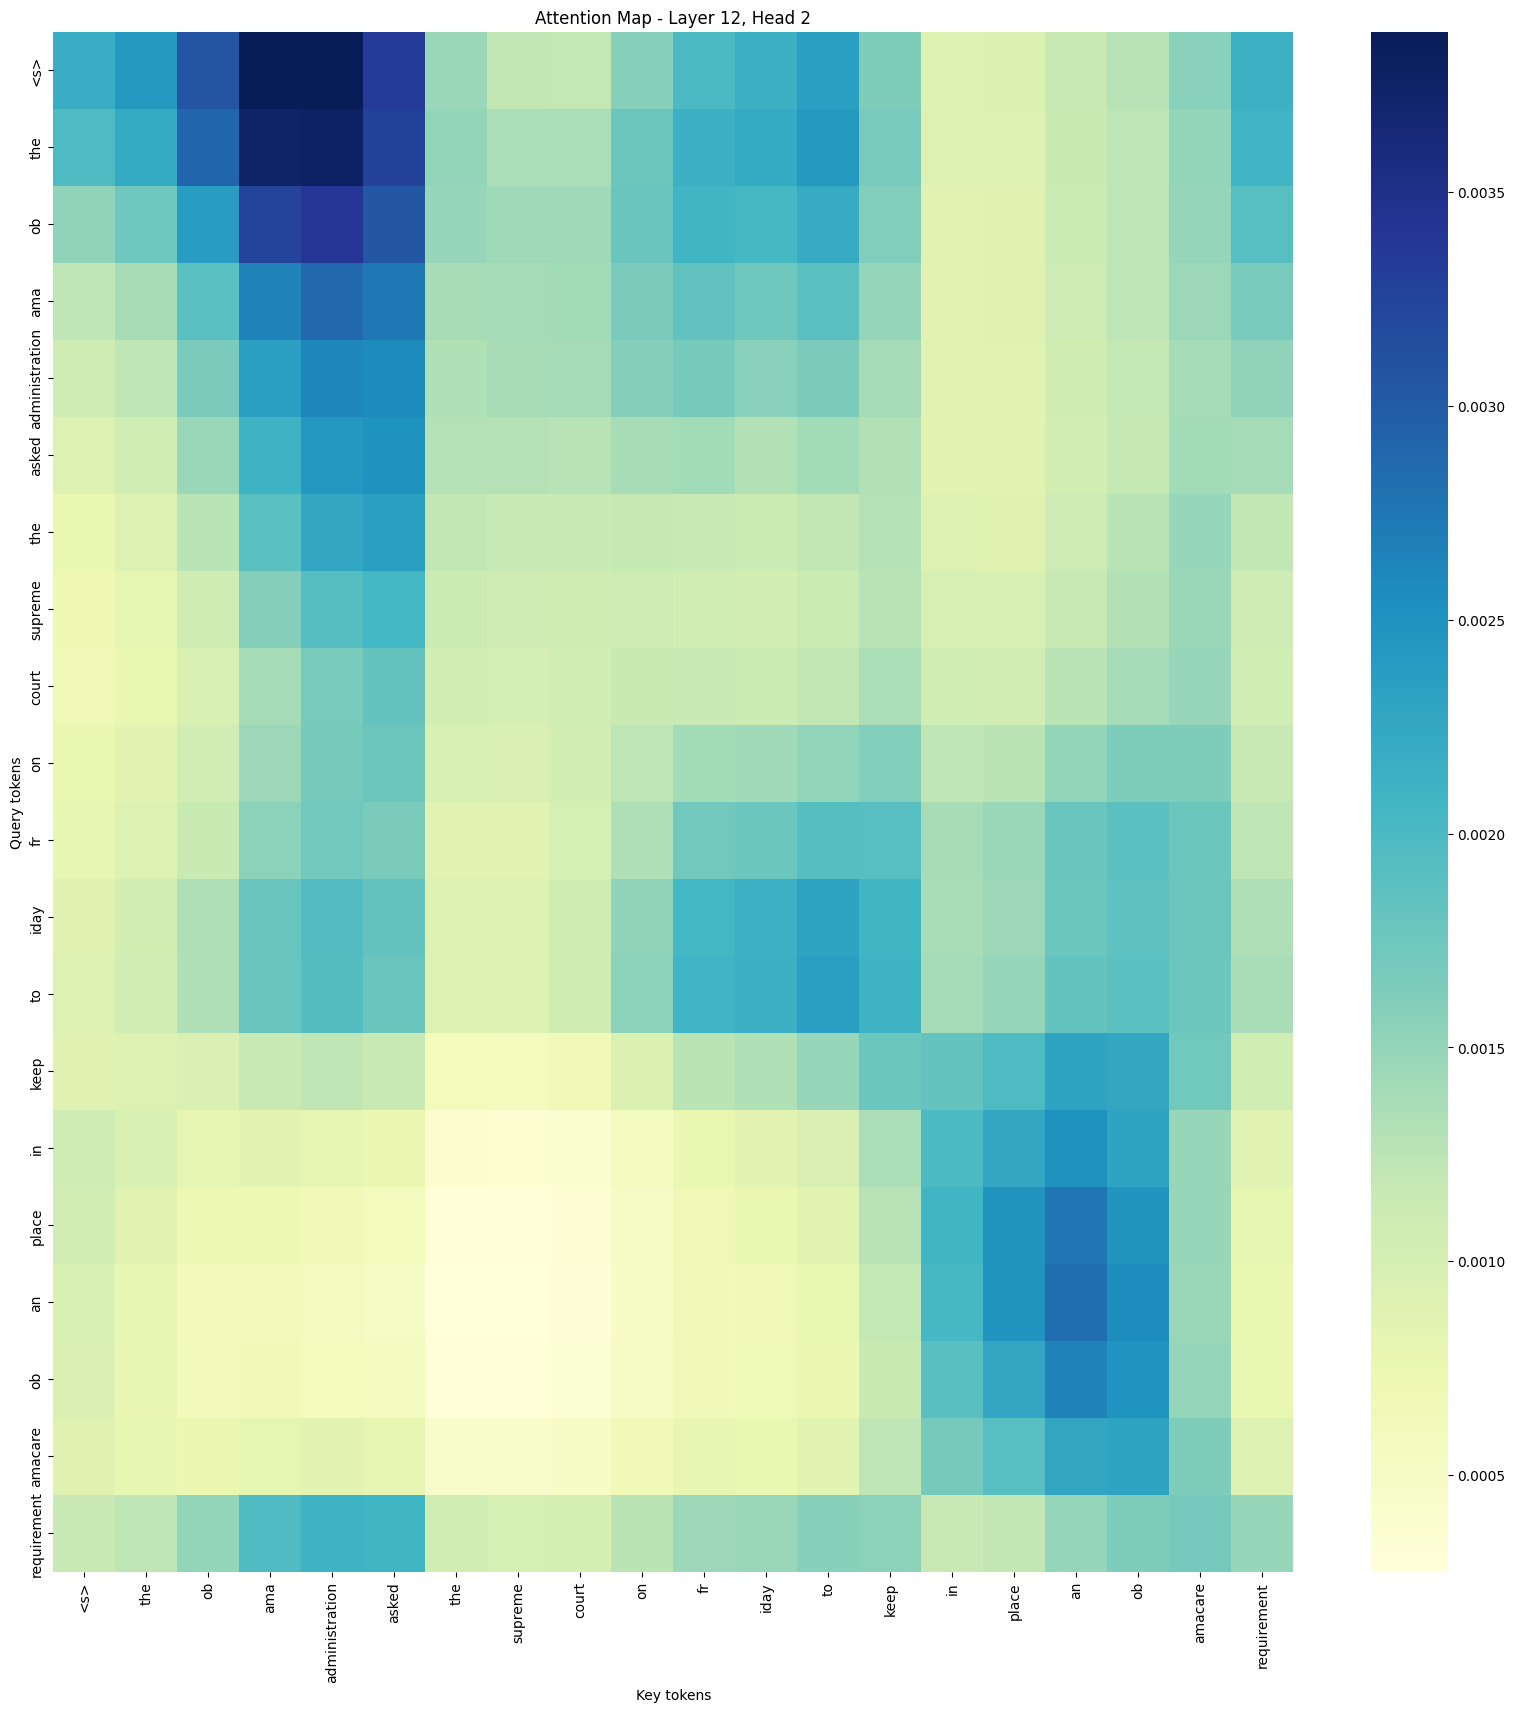

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

subset_tokens = tokens_alll[:20]
subset_attention = attention_matrix[:20, :20]

plt.figure(figsize=(20, 20))
sns.heatmap(subset_attention, xticklabels=subset_tokens, yticklabels=subset_tokens, cmap="YlGnBu", annot=False)
plt.xlabel("Key tokens")
plt.ylabel("Query tokens")
plt.title(f"Attention Map - Layer {layer+1}, Head {head+1}")
plt.show()

In [ ]:
from IPython.display import display, HTML

# Normalize values
from IPython.display import display, HTML

def visualize_attention(tokens, attention_scores):
    """
    Displays tokens colored by attention scores using a 3-zone gradient.
    Red→Yellow for high, Yellow→Green for medium, Dark Green for low attention.
    """
    output = ""
    imp=0
    avg=0
    unimp=0
    for token, score in zip(tokens, attention_scores):
        score = float(score)
        safe_token = html.escape(token)
        if score > 0.6:
            imp=imp+1
            # High attention → Red to Yellow
            red = 255
            green = int(255 * (1 - (score - 0.6) * (1/0.4)))  # (score - 0.6)/(1-0.6)
            blue = 0
        elif 0.3 < score <= 0.6:
            # Medium attention → Yellow to Green
            avg=avg+1
            red = int(255 * ((score - 0.3) * (1/0.3)))  # (score-0.3)/(0.6-0.3)
            green = 255
            blue = 0
        else:
            # Low attention → Dark Green
            unimp=unimp+1
            red = 0
            green = int(128 + (score / 0.3) * (127))  # from 128 (dark green) up to 255
            blue = 0

        color = f'rgb({red},{green},{blue})'
        output += f'<span style="color:{color}; font-weight:bold; font-size:16px;">{safe_token} </span>'

    display(HTML(output))

    print("Important tokens:",imp)
    print("Average tokens:",avg)
    print("Unimportant tokens:",unimp)

visualize_attention(tokens_alll, attention_scores)

Important tokens: 109
Average tokens: 456
Unimportant tokens: 199


In [ ]:
output = ""

imp=0
avg=0
unimp=0
import html
for token, score in zip(tokens_alll, attention_scores):
    safe_token = html.escape(token)
    if score > 0.6:
        imp=imp+1
        output += f'<span style="color:red; font-weight:bold;">{safe_token} </span>'
    elif 0.3 < score <= 0.6:
        avg=avg+1
        output += f'<span style="color:orange;">{safe_token} </span>'
    else:
        unimp=unimp+1
        output += f'<span style="color:green;">{safe_token} </span>'

# Display the HTML in Colab (NOT print)
display(HTML(output))

print("Important tokens:",imp)
print("Average tokens:",avg)
print("Unimportant tokens:",unimp)


Important tokens: 109
Average tokens: 456
Unimportant tokens: 199


In [ ]:
import torch

torch.cuda.empty_cache()
print("✅ Unused GPU memory cleared.")

✅ Unused GPU memory cleared.
